<a href="https://colab.research.google.com/github/Vishnu912py/time_series_forecasting/blob/main/Hierarchical_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA(Exploratory Data Analysis)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/Synthetic_Data_Full (1).csv")
display(df.head())

,ds,unique_id,y
0,01-01-2023,SMU-4_SL-2_Sector-03_ONSITE_FPP_NEW - NEW_1 st...,1
1,01-01-2023,SMU-2_SL-4_Sector-08_ONSITE_T&M_Old - Old_4 st...,1
2,01-01-2023,SMU-2_SL-2_Sector-07_OFFSHORE_T&M_NEW - NEW_4 ...,1
3,01-01-2023,SMU-3_SL-3_Sector-01_OFFSHORE_FPP_NEW - NEW_3 ...,1
4,01-01-2023,SMU-4_SL-1_Sector-06_ONSITE_FPP_NEW - NEW_2 st...,1


In [ ]:
df['ds'] = pd.to_datetime(df['ds'], format="%d-%m-%Y")

# Display the DataFrame information to confirm data types
print(df.info())

# Display the first few rows to show the format
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223210 entries, 0 to 223209
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   ds         223210 non-null  datetime64[ns]
 1   unique_id  223210 non-null  object        
 2   y          223210 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 5.1+ MB
None


,ds,unique_id,y
0,2023-01-01,SMU-4_SL-2_Sector-03_ONSITE_FPP_NEW - NEW_1 st...,1
1,2023-01-01,SMU-2_SL-4_Sector-08_ONSITE_T&M_Old - Old_4 st...,1
2,2023-01-01,SMU-2_SL-2_Sector-07_OFFSHORE_T&M_NEW - NEW_4 ...,1
3,2023-01-01,SMU-3_SL-3_Sector-01_OFFSHORE_FPP_NEW - NEW_3 ...,1
4,2023-01-01,SMU-4_SL-1_Sector-06_ONSITE_FPP_NEW - NEW_2 st...,1


In [ ]:
df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)

num_smu = df['SMU'].nunique()
num_sectors = df['Sector'].nunique()
num_service_lines = df['SL'].nunique()

print(f"Number of unique SMUs: {num_smu}")
print(f"Number of unique Sectors: {num_sectors}")
print(f"Number of unique Service Lines: {num_service_lines}")

Number of unique SMUs: 4
Number of unique Sectors: 14
Number of unique Service Lines: 4


In [ ]:
num_unique_ids = df['unique_id'].nunique()
print(f"Number of unique identifiers in 'unique_id' column: {num_unique_ids}")

Number of unique identifiers in 'unique_id' column: 219580


### The Macro View: What is the global trend and seasonality?

Aggregating your data into a **Weekly** format (rather than Daily or Monthly) is one of the most important decisions you can make in a B2B forecasting project.

In time series forecasting, the frequency of your data dictates both the math your computer can run and the business decisions your humans can make. Here is exactly why data scientists choose a weekly aggregation for HR and resource datasets.

### 1. The Mathematical Reason: "Smoothing the Noise"

Daily data in a corporate environment is incredibly noisy and chaotic.

* Client contracts get signed randomly on a Tuesday.
* Nobody requests new team members on a Saturday or Sunday.
* Holidays cause random zero-demand days.

If you feed daily data into AutoARIMA, the model gets confused by all the random spikes and weekend drops. It tries to predict the "noise" instead of the "signal." By grouping the data into 7-day buckets (Weekly), you mathematically smooth out those daily anomalies, allowing the algorithm to clearly see the true upward or downward trend of the skill.

### 2. The Statistical Reason: Fixing "Hyper-Sparsity"

We talked about using Croston's Method for "sparse" data (data with lots of zeros). However, if your data is *too* sparse, even Croston will fail.

* **Daily:** If a specific skill (like `SL-4 Offshore`) gets 2 requests a month, a daily view will have **28 days of zeros** and 2 days of data. That is a 93% sparsity rate. It is statistically impossible to predict exactly *which day* the next request will land on.
* **Weekly:** If you aggregate that same data by week, you might have 2 weeks with zeros and 2 weeks with a demand of 1. You just reduced your sparsity rate to 50%, which is the perfect sweet spot for Croston's method to accurately predict the *week* the demand will hit.

### 3. The Business Reason: "The HR Actionability Window"

A forecast is only valuable if a human can take action on it.

* **Daily is too fast:** If your model predicts Wipro needs 50 AI engineers "tomorrow," HR cannot do anything with that information. You cannot recruit, hire, or upskill a person in 24 hours.
* **Monthly is too slow:** If your model predicts you need 50 AI engineers "sometime in November," it is too vague. Resource managers need to assign people to client projects on specific dates to avoid losing billing hours.
* **Weekly is the Goldilocks Zone:** Predicting that "We will face a shortage of 50 AI engineers starting in Week 3 of Q2" aligns perfectly with how HR runs "sprints," schedules bootcamp training cohorts, and opens job requisitions.

### 4. The Computational Cost

Running a "Tournament" of multiple algorithms (ARIMA, ETS, Theta, Croston) across thousands of hierarchical nodes (Total $\rightarrow$ SMU $\rightarrow$ Sector $\rightarrow$ SL) requires massive computing power.

* **Daily Forecast (1 Year):** The computer has to calculate 365 steps into the future for every single node.
* **Weekly Forecast (1 Year):** The computer only calculates 52 steps into the future.
Weekly aggregation allows you to run complex enterprise models on a standard laptop in minutes instead of requiring a massive cloud server.

---

### Interactive Demonstration: The Aggregation Smoother

To physically see why the ARIMA algorithm "prefers" weekly data over daily data, try adjusting the aggregation level in the visualizer below. Watch how the hidden trend emerges as you change the time buckets, and notice how the Sparsity and Compute metrics change!

In [ ]:
df['ds'] = pd.to_datetime(df['ds'])

# 2. Extract the categorical features from unique_id
df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)

# 3. Set up plotting style
sns.set_theme(style="whitegrid")

# Create a weekly aggregated dataframe for easier plotting
weekly_data = df.groupby([pd.Grouper(key='ds', freq='W-MON'), 'SMU', 'SL', 'Sector']).sum(numeric_only=True).reset_index()

# Helper function to generate and save line plots for different hierarchy levels
def plot_level(level_name, filename, top_n=None):
    plt.figure(figsize=(12, 5))

    # Aggregate at the specific level
    agg_df = weekly_data.groupby(['ds', level_name])['y'].sum().reset_index()

    # If there are too many categories (like 14 Sectors), filter to top N for readability
    if top_n:
        top_cats = agg_df.groupby(level_name)['y'].sum().nlargest(top_n).index
        agg_df = agg_df[agg_df[level_name].isin(top_cats)]
        title_suffix = f" (Top {top_n})"
    else:
        title_suffix = ""

    sns.lineplot(data=agg_df, x='ds', y='y', hue=level_name, linewidth=2)
    plt.title(f'Weekly Demand by {level_name}{title_suffix}', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Demand (Placements)', fontsize=12)
    plt.legend(title=level_name, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# --- Generate the Plots ---

# Plot 1: Total Overall Demand
plt.figure(figsize=(12, 4))
total_weekly = df.groupby(pd.Grouper(key='ds', freq='W-MON'))['y'].sum().reset_index()
sns.lineplot(data=total_weekly, x='ds', y='y', color='black', linewidth=2)
plt.title('Total Overall Weekly Demand (Macro Trend)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.tight_layout()
plt.savefig('eda_total.png')
plt.close()

# Plot 2: Demand by SMU
plot_level('SMU', 'eda_smu.png')

# Plot 3: Demand by Service Line (SL)
plot_level('SL', 'eda_sl.png')

# Plot 4: Demand by Top 6 Sectors
plot_level('Sector', 'eda_sector_top6.png', top_n=6)

print("EDA plots successfully generated and saved to disk.")

EDA plots successfully generated and saved to disk.


### Total Overall Weekly Demand (Macro Trend)


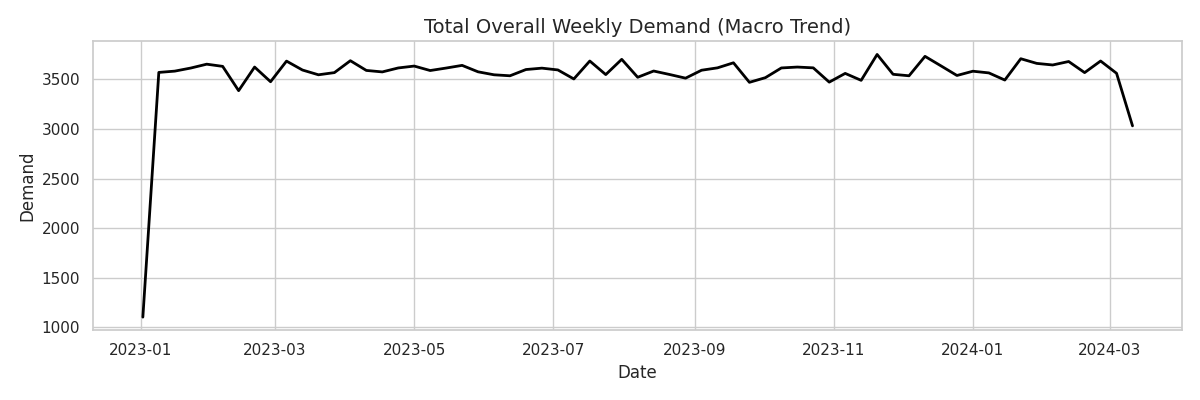

In [ ]:
from IPython.display import Image, display

print("### Total Overall Weekly Demand (Macro Trend)")
display(Image('eda_total.png'))

### Weekly Demand by SMU


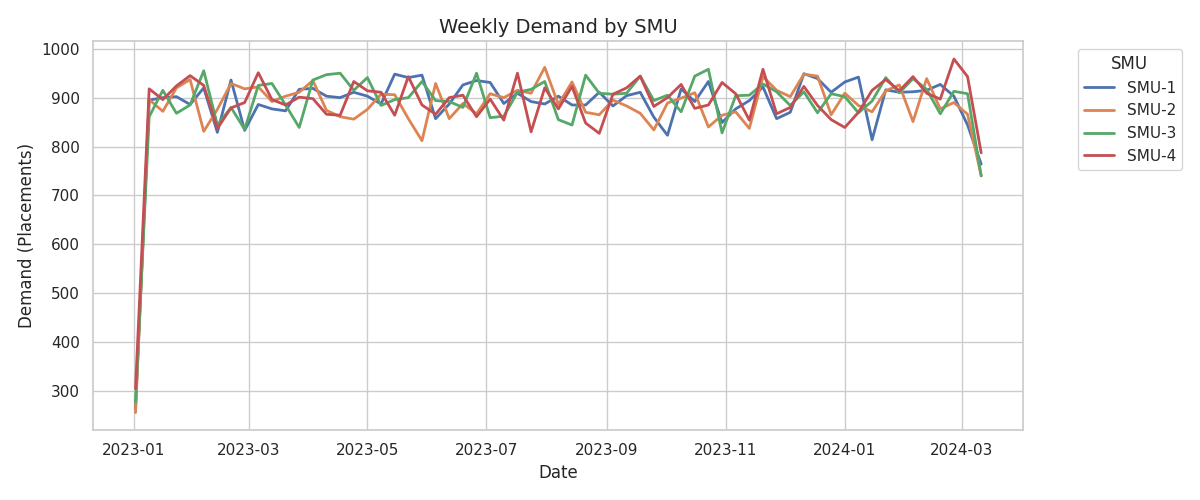

In [ ]:
print("### Weekly Demand by SMU")
display(Image('eda_smu.png'))

### Weekly Demand by Service Line (SL)


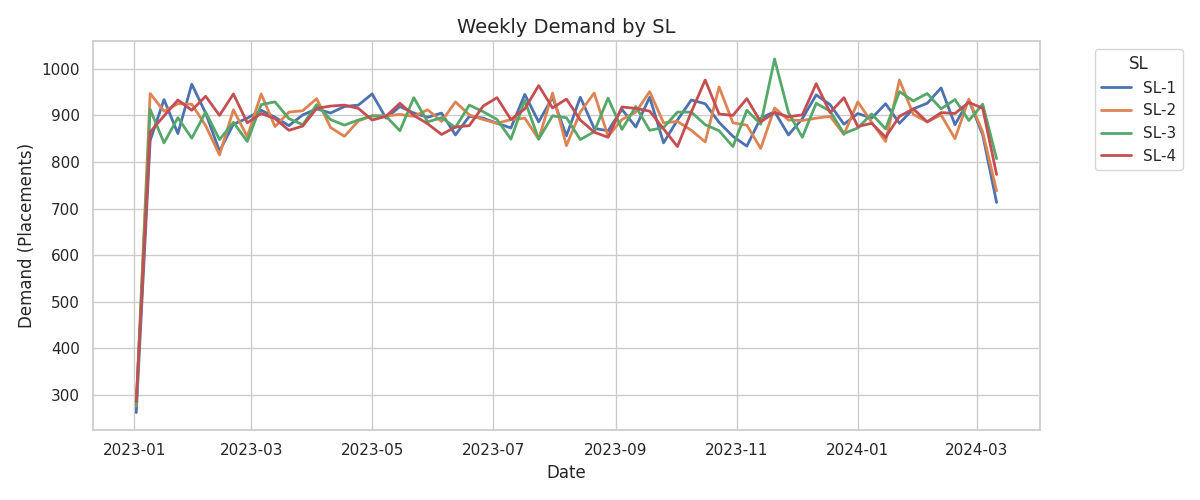

In [ ]:
print("### Weekly Demand by Service Line (SL)")
display(Image('eda_sl.png'))

### Weekly Demand by Top 6 Sectors


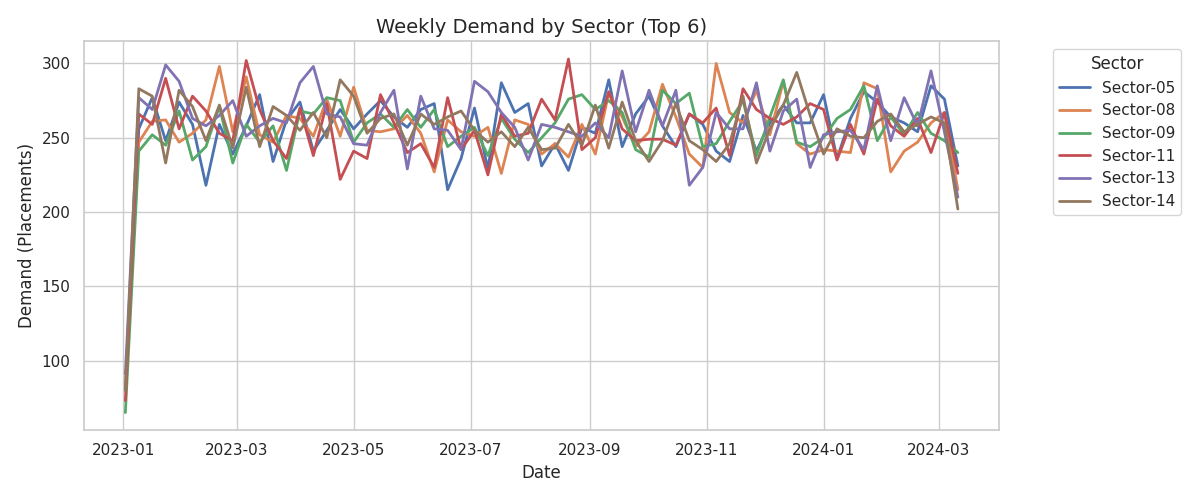

In [ ]:
print("### Weekly Demand by Top 6 Sectors")
display(Image('eda_sector_top6.png'))

In [ ]:
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


,0
ds,0
unique_id,0
y,0
SMU,0
SL,0
Sector,0
Location,0
Pricing,0
Type,0
Star,0


### Augmented Dickey-Fuller Test for Stationarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the total overall weekly demand
result = adfuller(total_weekly['y'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print("\nBased on the p-value (%.3f), the series is stationary." % result[1])
else:
    print("\nBased on the p-value (%.3f), the series is not stationary." % result[1])

ADF Statistic: -25.203942
p-value: 0.000000
Critical Values:
	1%: -3.541
	5%: -2.909
	10%: -2.592

Based on the p-value (0.000), the series is stationary.


### Total Overall Weekly Demand Plot

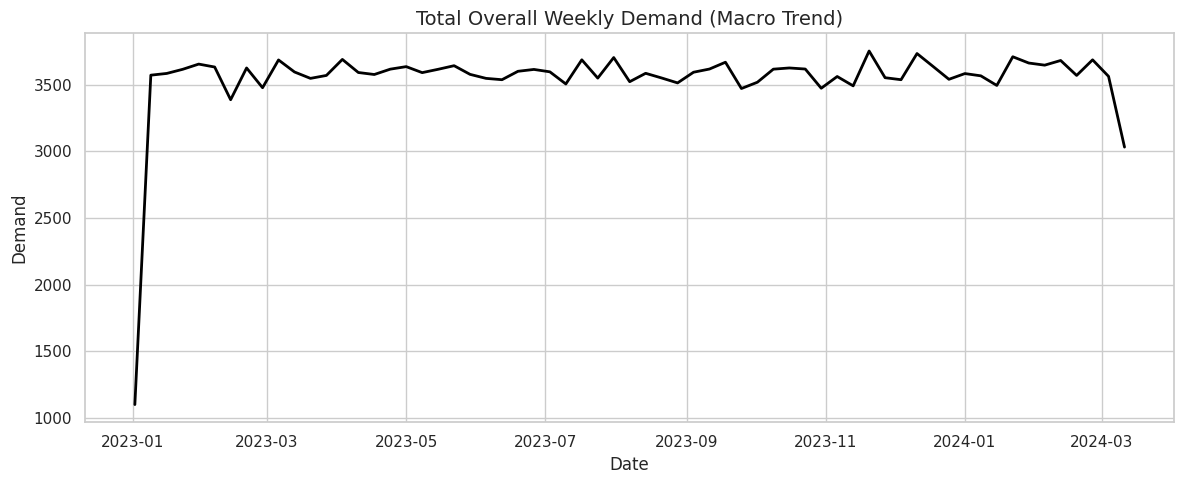

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=total_weekly, x='ds', y='y', color='black', linewidth=2)
plt.title('Total Overall Weekly Demand (Macro Trend)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.tight_layout()
plt.show()

### Distribution of Weekly Demand (y)

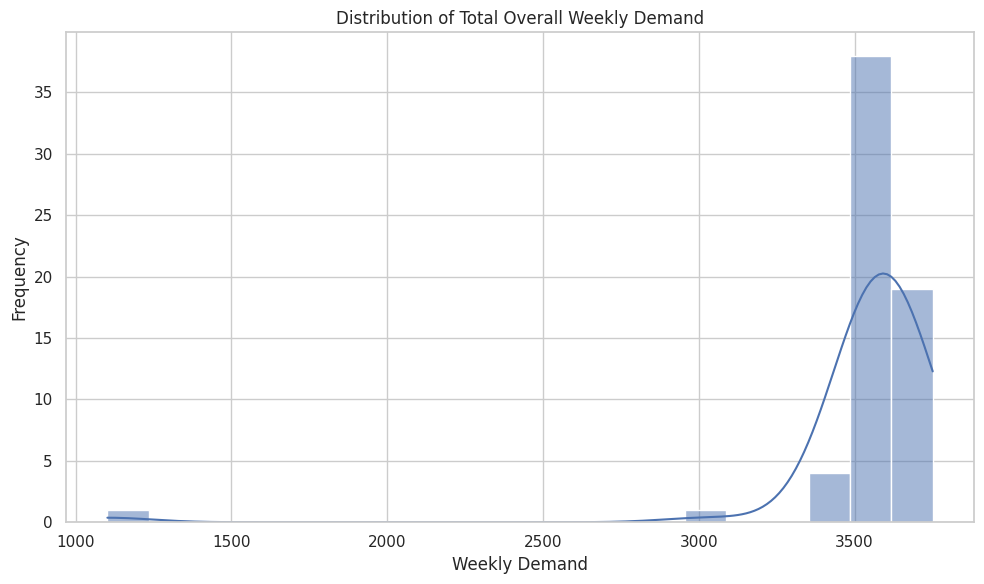

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(total_weekly['y'], kde=True, bins=20)
plt.title('Distribution of Total Overall Weekly Demand')
plt.xlabel('Weekly Demand')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Autocorrelation Function (ACF) of Weekly Demand

<Figure size 1200x500 with 0 Axes>

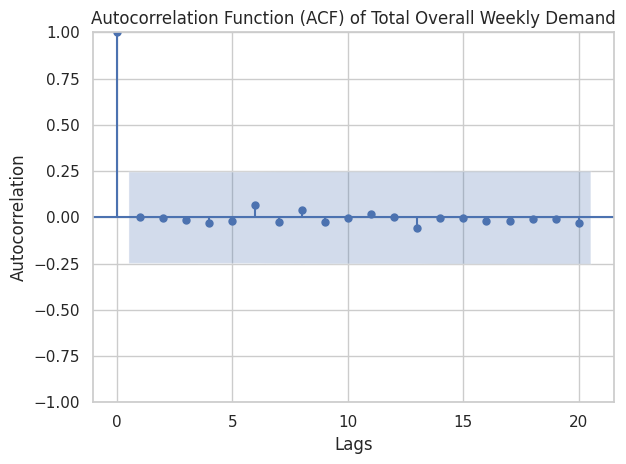

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))
plot_acf(total_weekly['y'], lags=20)
plt.title('Autocorrelation Function (ACF) of Total Overall Weekly Demand')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

### Autocorrelation Function (ACF) Plots by Category

Generating ACF plots for each SMU...


<Figure size 1000x400 with 0 Axes>

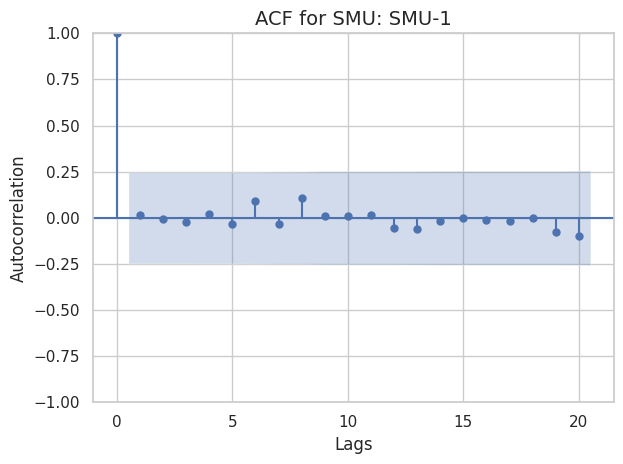

<Figure size 1000x400 with 0 Axes>

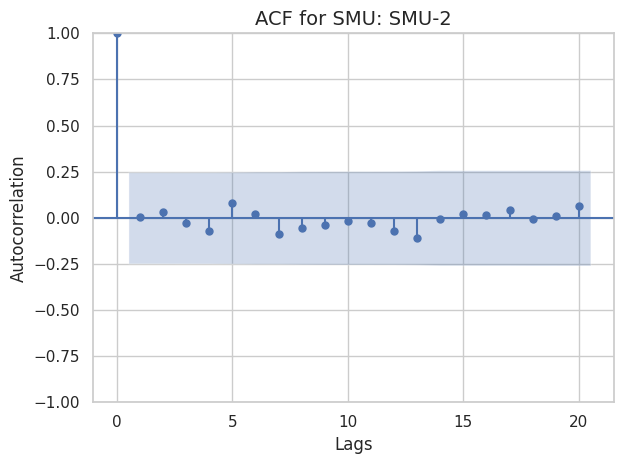

<Figure size 1000x400 with 0 Axes>

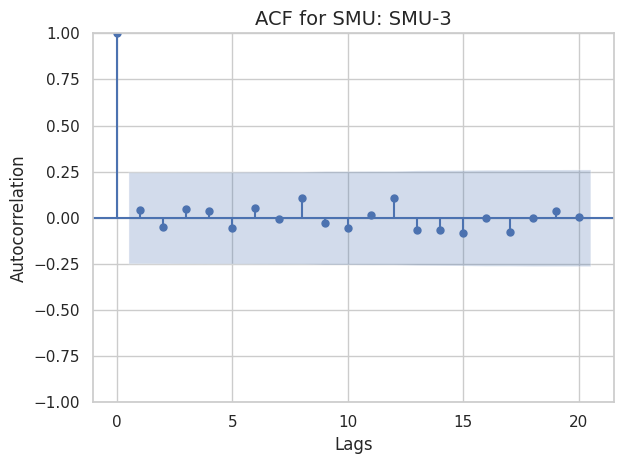

<Figure size 1000x400 with 0 Axes>

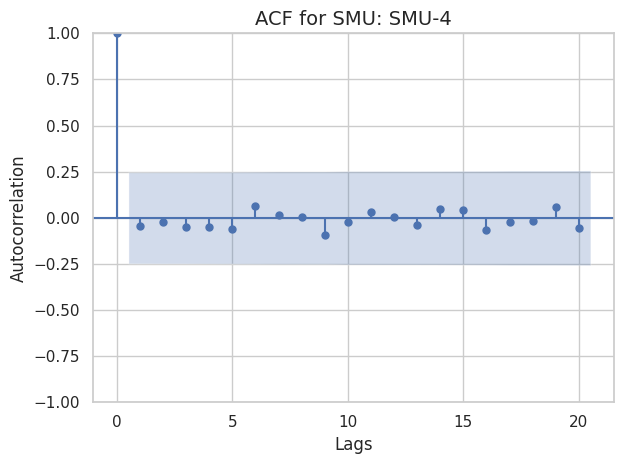

Generating ACF plots for each Service Line (SL)...


<Figure size 1000x400 with 0 Axes>

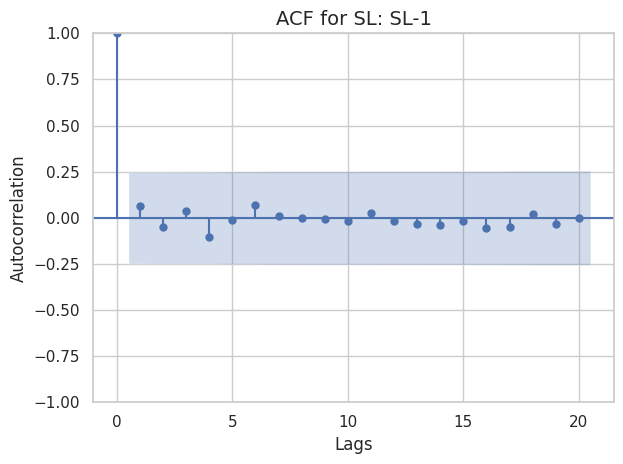

<Figure size 1000x400 with 0 Axes>

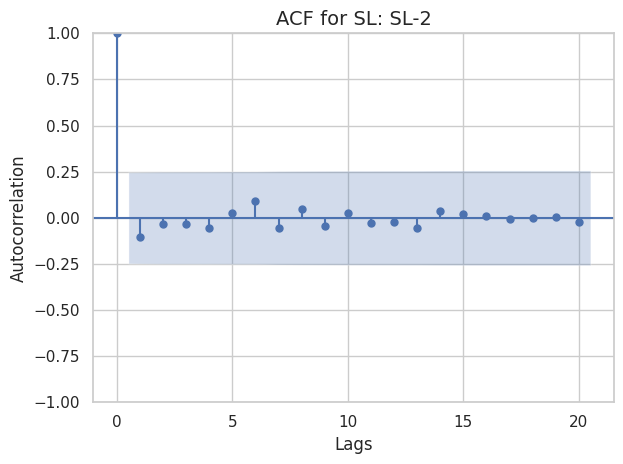

<Figure size 1000x400 with 0 Axes>

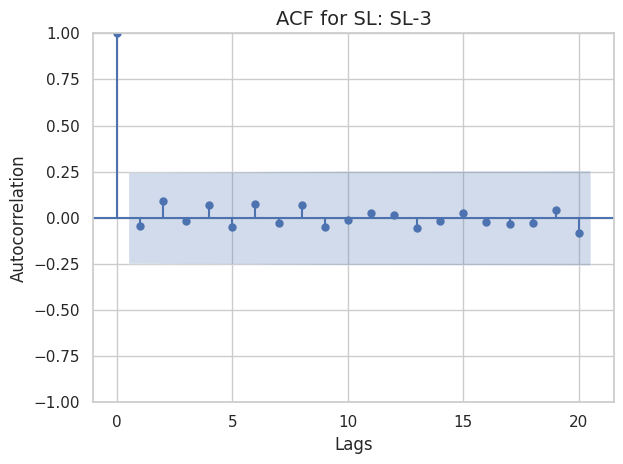

<Figure size 1000x400 with 0 Axes>

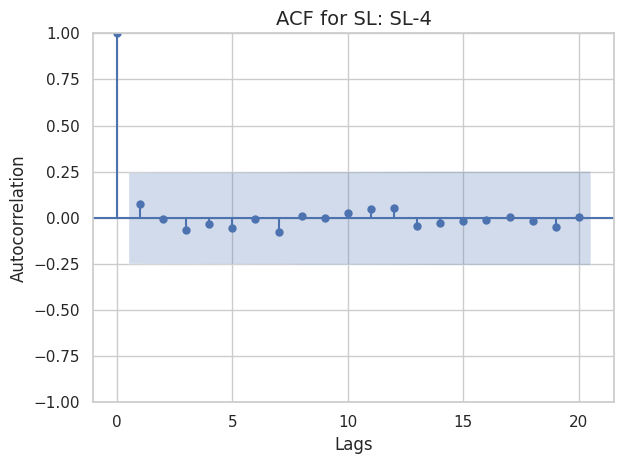

Generating ACF plots for each Sector...


<Figure size 1000x400 with 0 Axes>

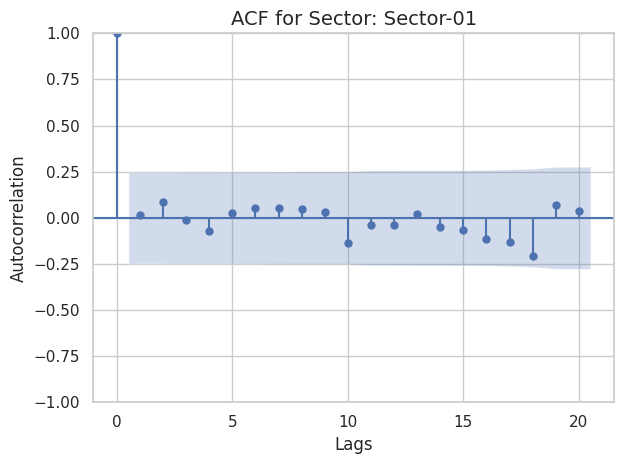

<Figure size 1000x400 with 0 Axes>

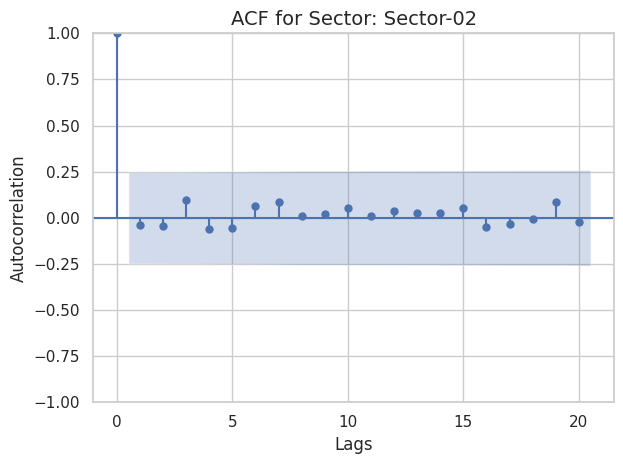

<Figure size 1000x400 with 0 Axes>

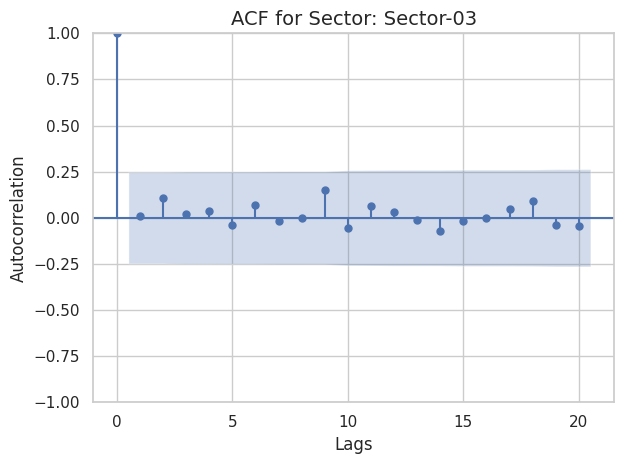

<Figure size 1000x400 with 0 Axes>

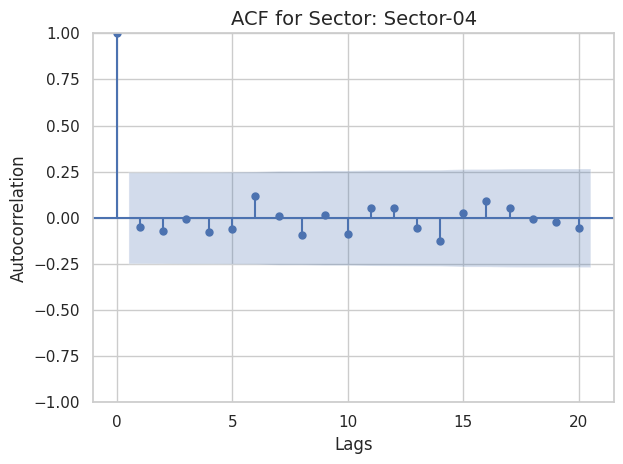

<Figure size 1000x400 with 0 Axes>

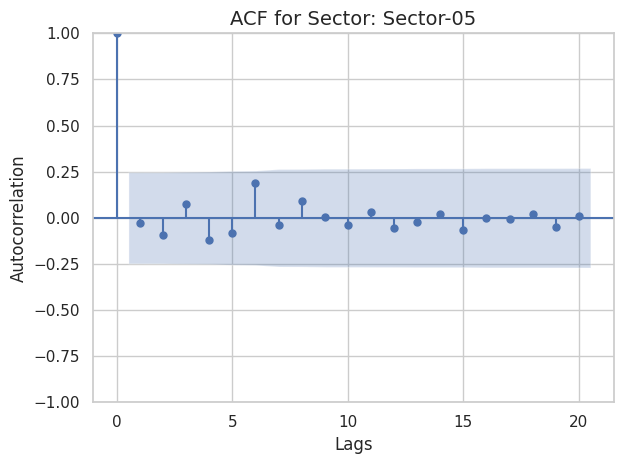

<Figure size 1000x400 with 0 Axes>

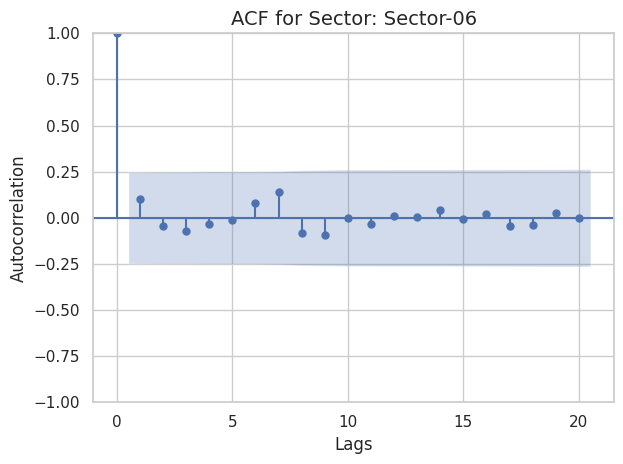

<Figure size 1000x400 with 0 Axes>

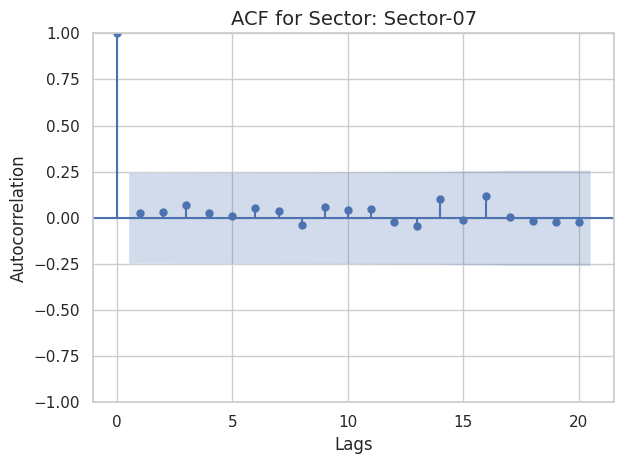

<Figure size 1000x400 with 0 Axes>

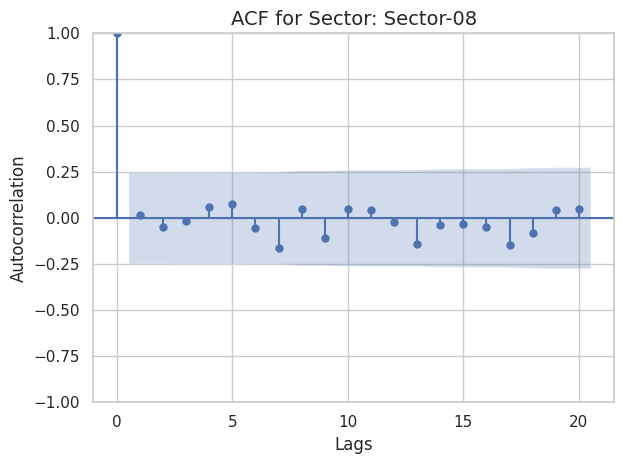

<Figure size 1000x400 with 0 Axes>

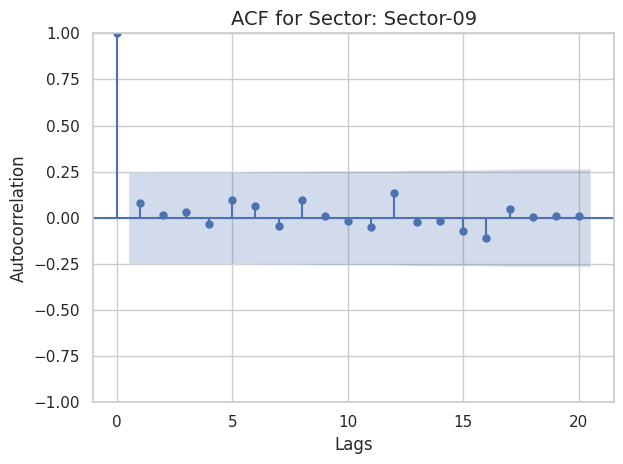

<Figure size 1000x400 with 0 Axes>

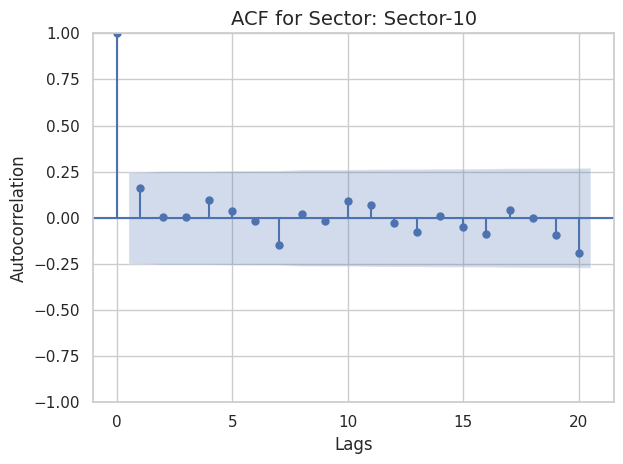

<Figure size 1000x400 with 0 Axes>

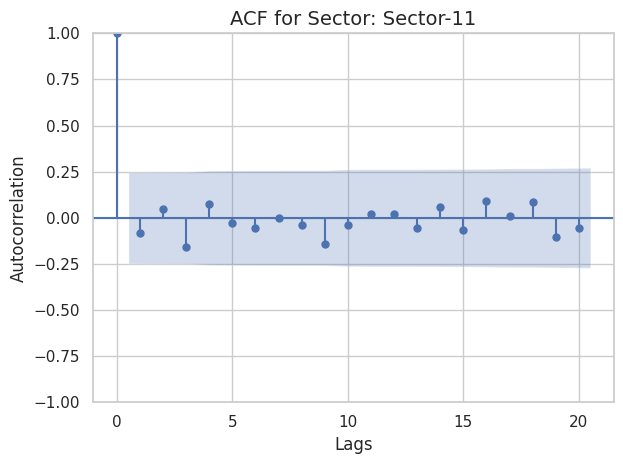

<Figure size 1000x400 with 0 Axes>

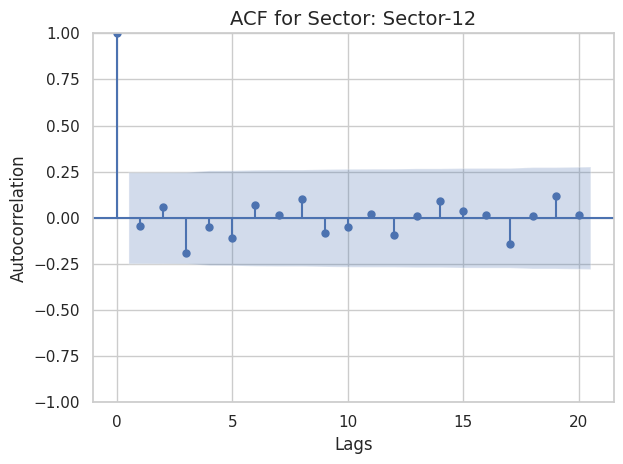

<Figure size 1000x400 with 0 Axes>

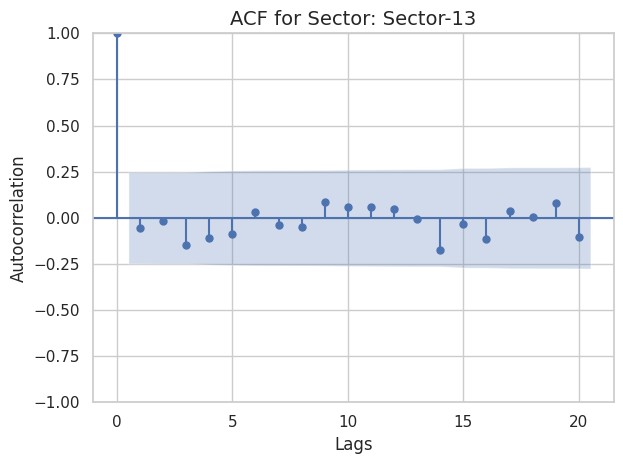

<Figure size 1000x400 with 0 Axes>

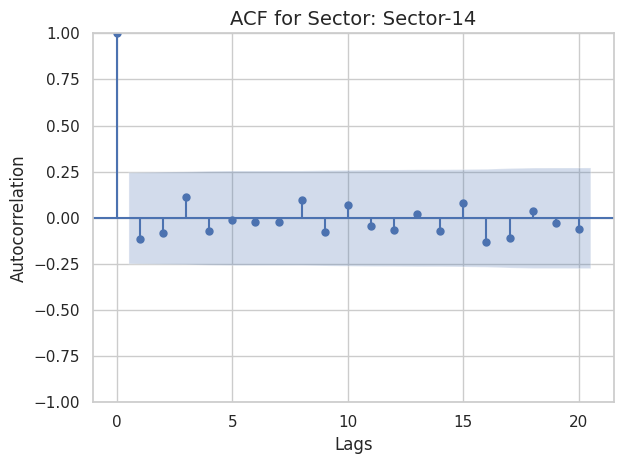

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

def plot_acf_by_category(data_df, category_col, value_col='y', lags=20):
    """
    Generates and displays ACF plots for each unique value within a specified categorical column.

    Args:
        data_df (pd.DataFrame): The DataFrame containing the time series data.
        category_col (str): The name of the categorical column to group by.
        value_col (str): The name of the column containing the time series values.
        lags (int): The number of lags to display in the ACF plot.
    """
    unique_categories = data_df[category_col].unique()
    for category in unique_categories:
        # Filter data for the current category and aggregate 'y' by 'ds'
        category_series = data_df[data_df[category_col] == category].groupby('ds')[value_col].sum()

        plt.figure(figsize=(10, 4))
        plot_acf(category_series, lags=lags)
        plt.title(f'ACF for {category_col}: {category}', fontsize=14)
        plt.xlabel('Lags', fontsize=12)
        plt.ylabel('Autocorrelation', fontsize=12)
        plt.tight_layout()
        plt.show()

print("Generating ACF plots for each SMU...")
plot_acf_by_category(weekly_data, 'SMU')

print("Generating ACF plots for each Service Line (SL)...")
plot_acf_by_category(weekly_data, 'SL')

print("Generating ACF plots for each Sector...")
plot_acf_by_category(weekly_data, 'Sector')

### Weekly Seasonality (Day of Week)

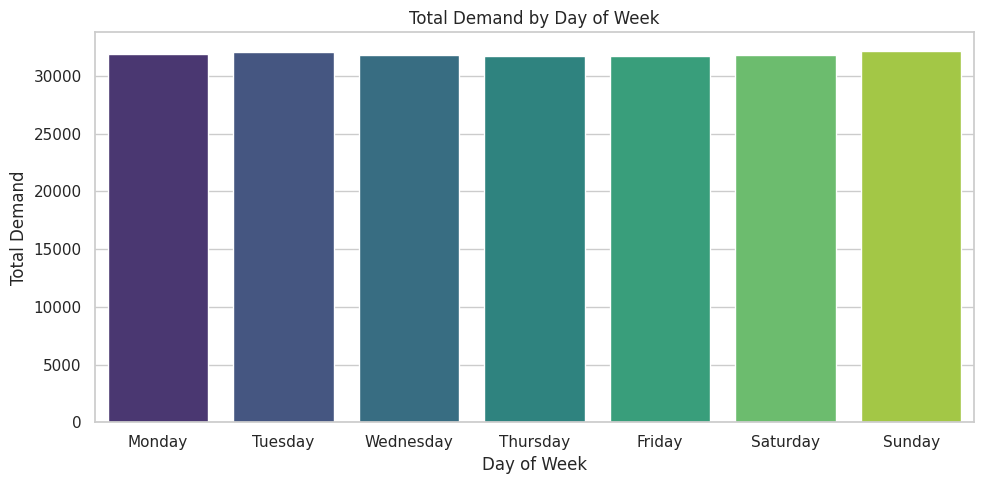

In [ ]:
# Extract day of the week (Monday=0, Sunday=6) from the original df
df['day_of_week'] = df['ds'].dt.dayofweek

# Aggregate demand by day of the week
daily_avg_demand = df.groupby('day_of_week')['y'].sum().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg_demand['day_name'] = daily_avg_demand['day_of_week'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 5))
sns.barplot(x='day_name', y='y', data=daily_avg_demand, palette='viridis', hue='day_name', legend=False)
plt.title('Total Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Demand')
plt.tight_layout()
plt.show()

### Monthly Seasonality

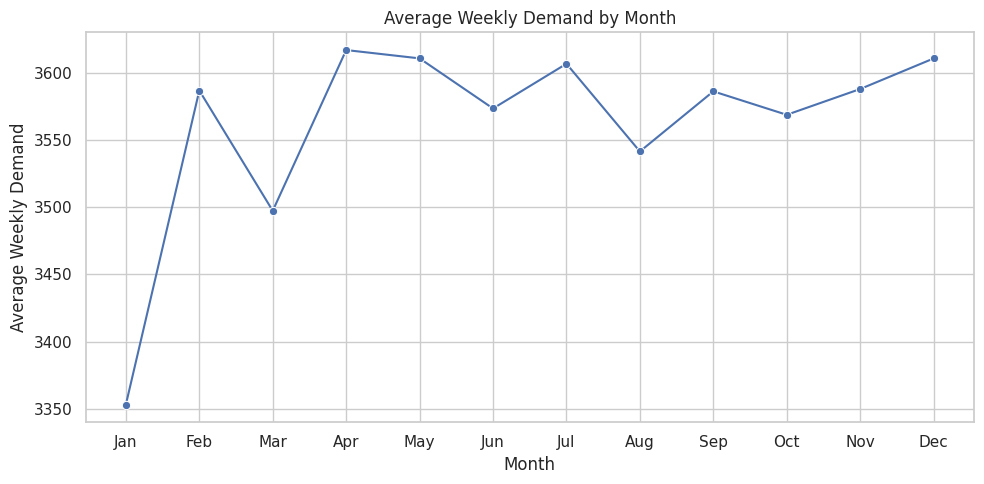

In [ ]:
# Extract month from the total_weekly DataFrame
total_weekly['month'] = total_weekly['ds'].dt.month

# Aggregate demand by month
monthly_avg_demand = total_weekly.groupby('month')['y'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='month', y='y', data=monthly_avg_demand, marker='o')
plt.title('Average Weekly Demand by Month')
plt.xlabel('Month')
plt.ylabel('Average Weekly Demand')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

### Quarterly Seasonality

### Checking for Intermittent Demand

In [ ]:
# Count the number of zero demand values in the original 'y' column
zero_demand_count = (df['y'] == 0).sum()
total_demand_count = len(df['y'])

print(f"Number of zero demand values: {zero_demand_count}")
print(f"Total number of demand values: {total_demand_count}")

if zero_demand_count > 0:
    percentage_zero = (zero_demand_count / total_demand_count) * 100
    print(f"Percentage of zero demand values: {percentage_zero:.2f}%")
    if percentage_zero > 10:
        print("\nThis suggests that the demand might be intermittent, and methods like Croston or ADIDA could be considered.")
    else:
        print("\nThe percentage of zero demand is relatively low, suggesting the demand is not strongly intermittent.")
else:
    print("\nThere are no zero demand values in the dataset, indicating that the demand is not intermittent.")

Number of zero demand values: 0
Total number of demand values: 223210

There are no zero demand values in the dataset, indicating that the demand is not intermittent.


### Seasonal Decomposition of Total Weekly Demand

Does not capture the hidden seasonalities because it uses OLS(ordinary least squares) algorithm to extract out seasonalities

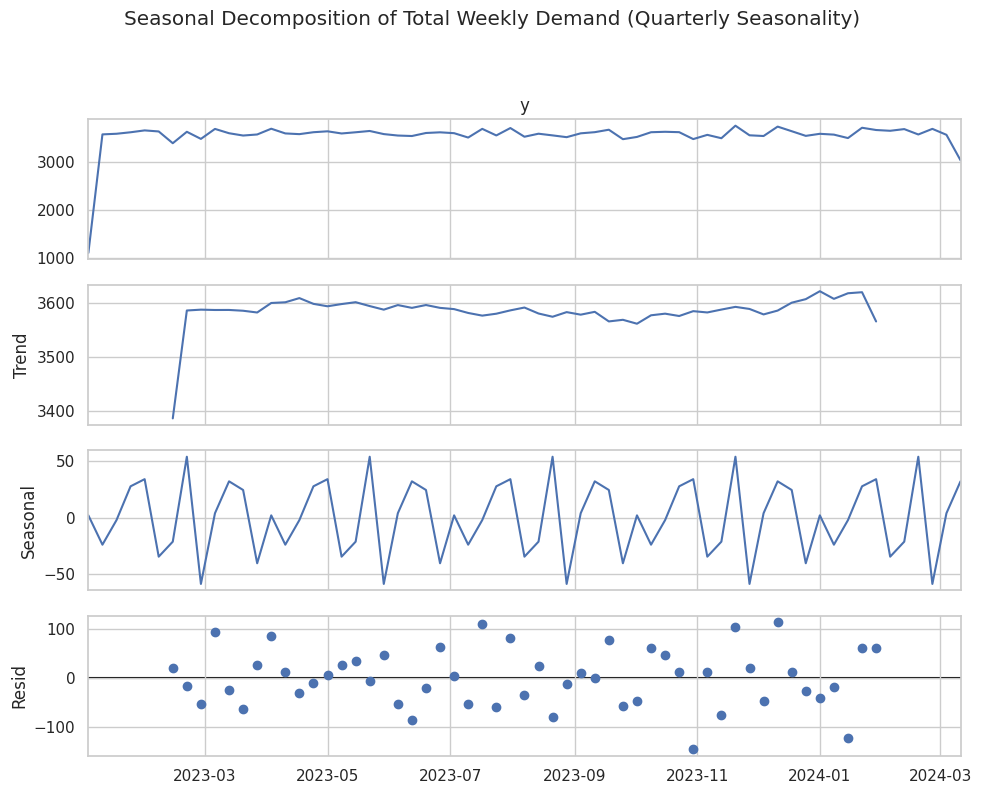

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set the 'ds' column as the index for seasonal decomposition
total_weekly_indexed = total_weekly.set_index('ds')

# Perform seasonal decomposition
# We'll use an additive model as the seasonal variations don't seem to increase with the level of the series
# The frequency is set to 13, representing approximate quarterly seasonality within weekly data, as 52 weeks requires more data.
# Our data has 63 observations, which is sufficient for two 13-week cycles (2*13=26).
decomposition = seasonal_decompose(total_weekly_indexed['y'], model='additive', period=13)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.suptitle('Seasonal Decomposition of Total Weekly Demand (Quarterly Seasonality)', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

### Multi-Seasonal Time Series Decomposition (MSTL)

It uses MSTL and an efficient algorithm LOESS(locally estimable scatterplot smoothing). This is algorithm which uses local regression. We can have the visualization of the algorithm similar "peeling" process

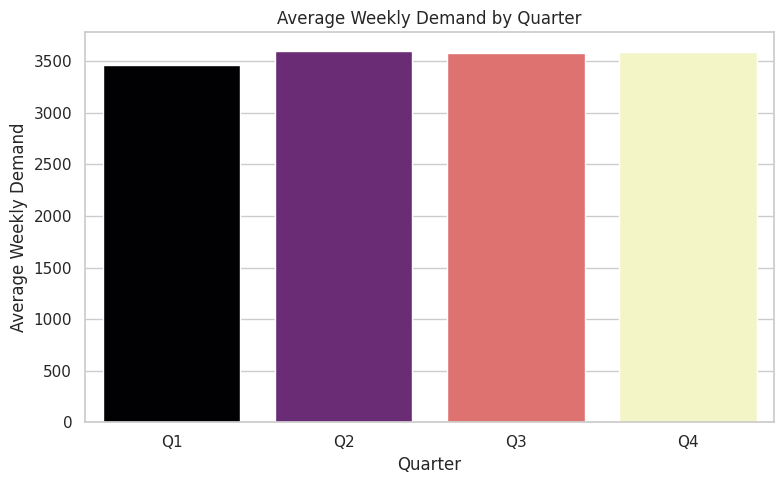

In [ ]:
# Extract quarter from the total_weekly DataFrame
total_weekly['quarter'] = total_weekly['ds'].dt.quarter

# Aggregate demand by quarter
quarterly_avg_demand = total_weekly.groupby('quarter')['y'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='quarter', y='y', data=quarterly_avg_demand, palette='magma', hue='quarter', legend=False)
plt.title('Average Weekly Demand by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Weekly Demand')
plt.xticks(range(0, 4), ['Q1', 'Q2', 'Q3', 'Q4'])
plt.tight_layout()
plt.show()

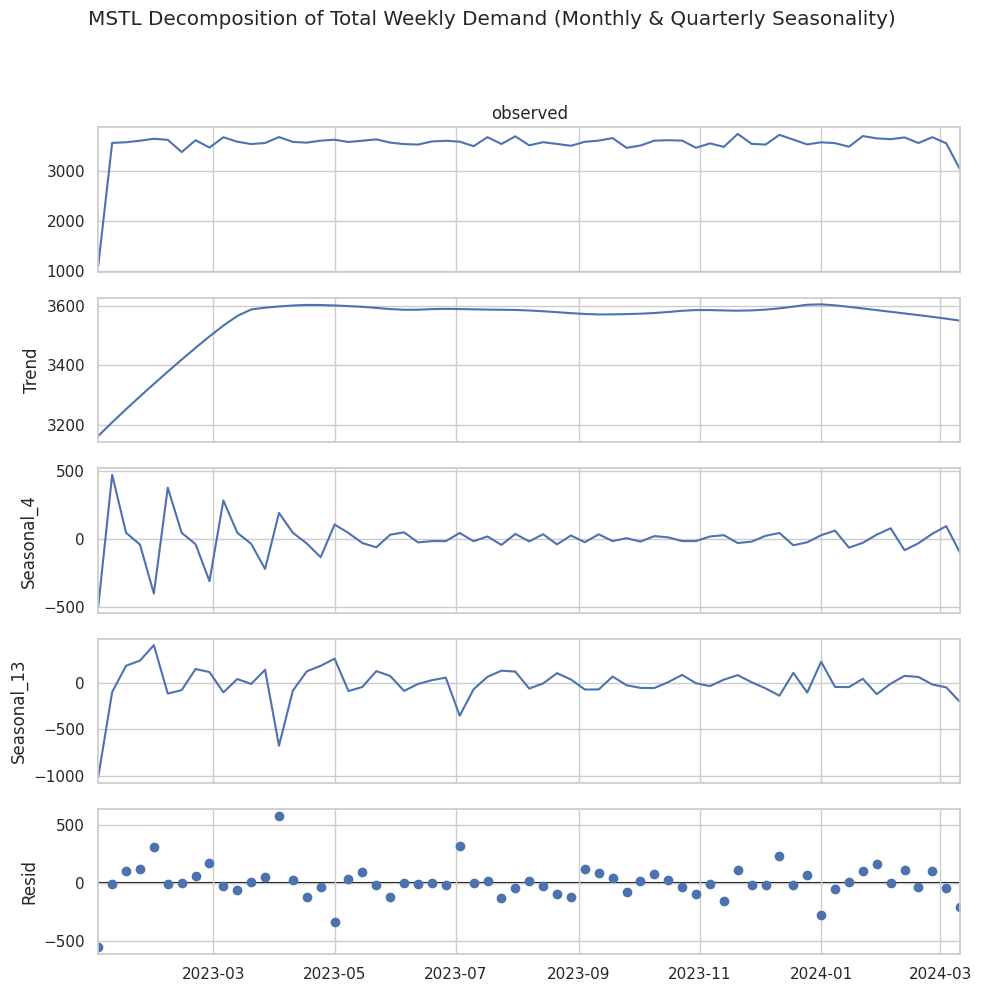

In [ ]:
from statsmodels.tsa.seasonal import MSTL

# The total_weekly_indexed DataFrame is already set up with 'ds' as index
# We'll use periods for approximate monthly (4 weeks) and quarterly (13 weeks) seasonality
mstl_decomposition = MSTL(total_weekly_indexed['y'], periods=[4, 13])
res = mstl_decomposition.fit()

# Plot the decomposed components
fig = res.plot()
fig.set_size_inches(10, 10) # Adjust figure size for better readability
plt.suptitle('MSTL Decomposition of Total Weekly Demand (Monthly & Quarterly Seasonality)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Seasonality Strength from MSTL Decomposition

In [ ]:
import numpy as np

# Calculate overall seasonality strength
# Overall seasonality strength = max(0, 1 - Var(Residual) / Var(Observed - Trend))
observed_minus_trend = res.observed - res.trend
overall_seasonal_strength = np.maximum(0, 1 - (res.resid.var() / observed_minus_trend.var()))

# Calculate individual seasonality strengths for each period
# Strength_p = max(0, 1 - Var(Residual) / Var(Seasonal_p + Residual))
strength_seasonal_4 = np.maximum(0, 1 - (res.resid.var() / (res.seasonal['seasonal_4'] + res.resid).var()))
strength_seasonal_13 = np.maximum(0, 1 - (res.resid.var() / (res.seasonal['seasonal_13'] + res.resid).var()))

print("Seasonality Strengths (from MSTL Decomposition):")
print(f"  Seasonal Period 4 (weeks) Strength: {strength_seasonal_4:.4f}")
print(f"  Seasonal Period 13 (weeks) Strength: {strength_seasonal_13:.4f}")
print(f"Overall Seasonality Strength: {overall_seasonal_strength:.4f}")

Seasonality Strengths (from MSTL Decomposition):
  Seasonal Period 4 (weeks) Strength: 0.5114
  Seasonal Period 13 (weeks) Strength: 0.6321
Overall Seasonality Strength: 0.7315


### Splitting Data into Training and Testing Sets

In [ ]:
# Define the split date. Let's use approximately the last 8 weeks for the test set.
split_date = pd.to_datetime('2024-01-15')

# Split the total_weekly DataFrame into training and testing sets
train_total_weekly = total_weekly[total_weekly['ds'] < split_date]
test_total_weekly = total_weekly[total_weekly['ds'] >= split_date]

print(f"Training set starts: {train_total_weekly['ds'].min()} and ends: {train_total_weekly['ds'].max()}")
print(f"Testing set starts: {test_total_weekly['ds'].min()} and ends: {test_total_weekly['ds'].max()}")

# Calculate and display the percentage of data in training and testing sets
total_observations = len(total_weekly)
train_percentage = (len(train_total_weekly) / total_observations) * 100
test_percentage = (len(test_total_weekly) / total_observations) * 100

print(f"Training set contains {len(train_total_weekly)} observations ({train_percentage:.2f}% of total data).")
print(f"Testing set contains {len(test_total_weekly)} observations ({test_percentage:.2f}% of total data).")

display(train_total_weekly.head())
display(test_total_weekly.head())

Training set starts: 2023-01-02 00:00:00 and ends: 2024-01-08 00:00:00
Testing set starts: 2024-01-15 00:00:00 and ends: 2024-03-11 00:00:00
Training set contains 54 observations (85.71% of total data).
Testing set contains 9 observations (14.29% of total data).


,ds,y,month,quarter
0,2023-01-02,1102,1,1
1,2023-01-09,3570,1,1
2,2023-01-16,3583,1,1
3,2023-01-23,3614,1,1
4,2023-01-30,3653,1,1


,ds,y,month,quarter
54,2024-01-15,3493,1,1
55,2024-01-22,3708,1,1
56,2024-01-29,3661,1,1
57,2024-02-05,3645,2,1
58,2024-02-12,3680,2,1


### Re-performing MSTL Decomposition on the Training Set

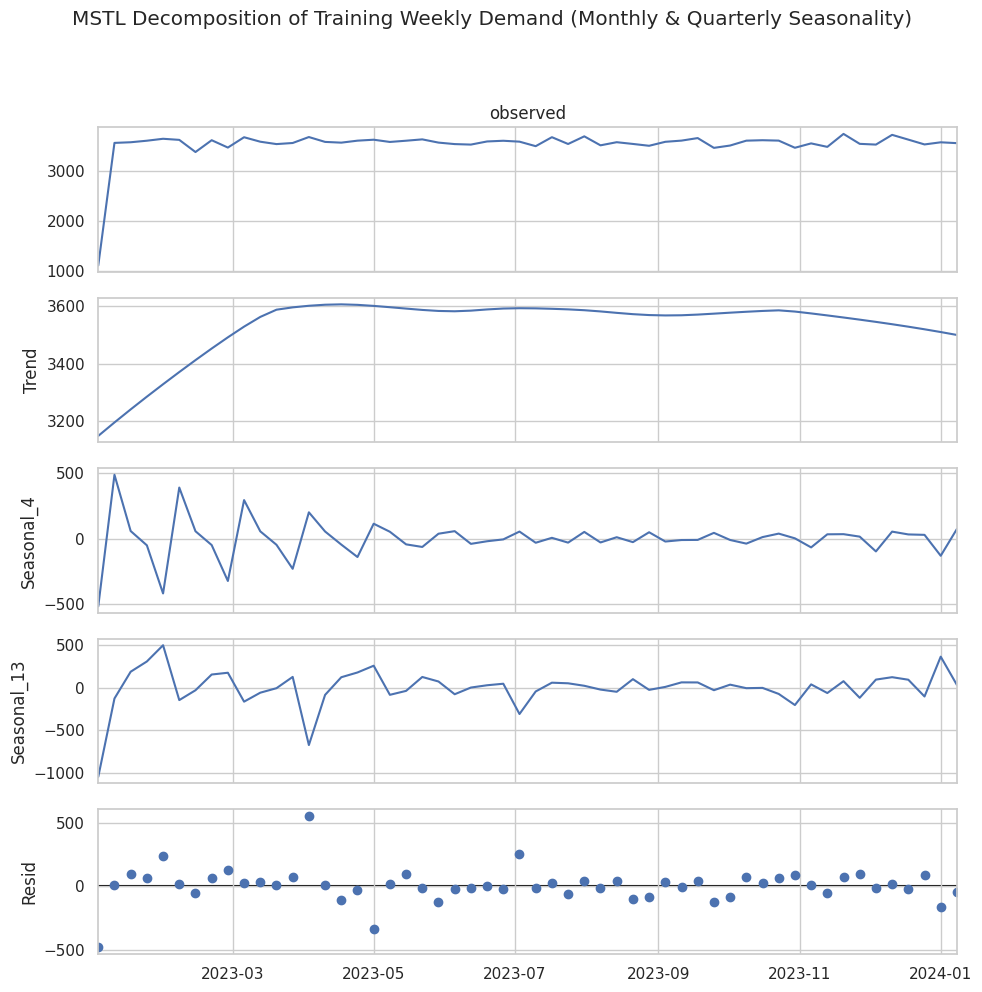

In [ ]:
from statsmodels.tsa.seasonal import MSTL

# Set the 'ds' column as the index for the training set for MSTL
train_total_weekly_indexed = train_total_weekly.set_index('ds')

# Perform MSTL decomposition on the training data
mstl_decomposition_train = MSTL(train_total_weekly_indexed['y'], periods=[4, 13])
res_train = mstl_decomposition_train.fit()

# Plot the decomposed components for the training set
fig_train = res_train.plot()
fig_train.set_size_inches(10, 10)
plt.suptitle('MSTL Decomposition of Training Weekly Demand (Monthly & Quarterly Seasonality)', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

This MSTL decomposition on the training set helps us understand the seasonal components present in the data that the model will be trained on. This is important for developing an accurate forecasting model.

### Visualizing Residuals from MSTL Decomposition (Training Set)

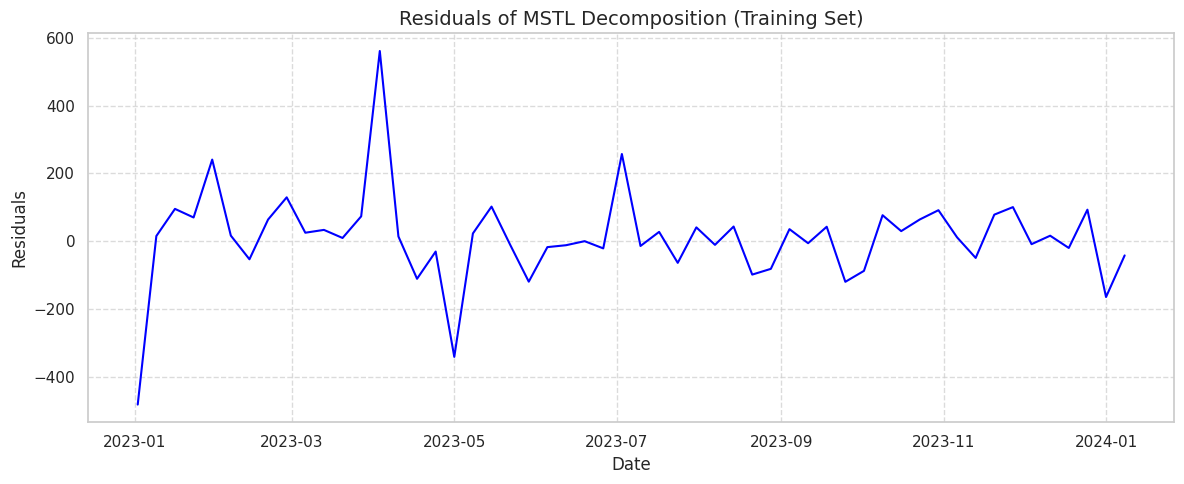

<Figure size 1200x500 with 0 Axes>

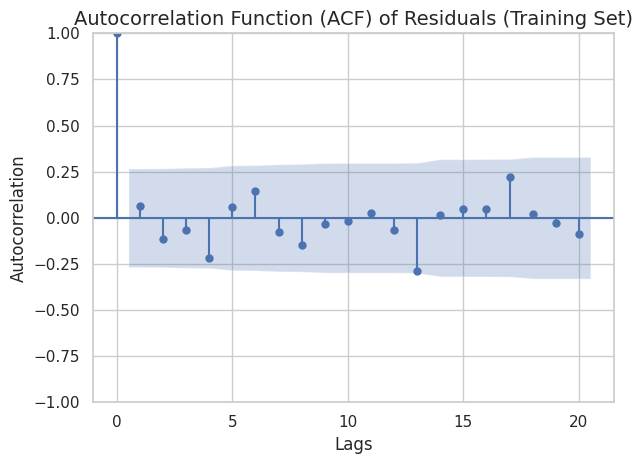

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Plot the residuals
plt.figure(figsize=(12, 5))
sns.lineplot(x=res_train.resid.index, y=res_train.resid, color='blue')
plt.title('Residuals of MSTL Decomposition (Training Set)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot the ACF of the residuals
plt.figure(figsize=(12, 5))
plot_acf(res_train.resid, lags=20)
plt.title('Autocorrelation Function (ACF) of Residuals (Training Set)', fontsize=14)
plt.xlabel('Lags', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.tight_layout()
plt.show()

Ideally, the residuals should appear as white noise, meaning they should be randomly scattered around zero with no discernible patterns, and their ACF plot should show no significant autocorrelations at any lag. If patterns are observed, it suggests that the decomposition did not fully capture all systematic variations in the data.

### Histogram of Residuals from MSTL Decomposition (Training Set)

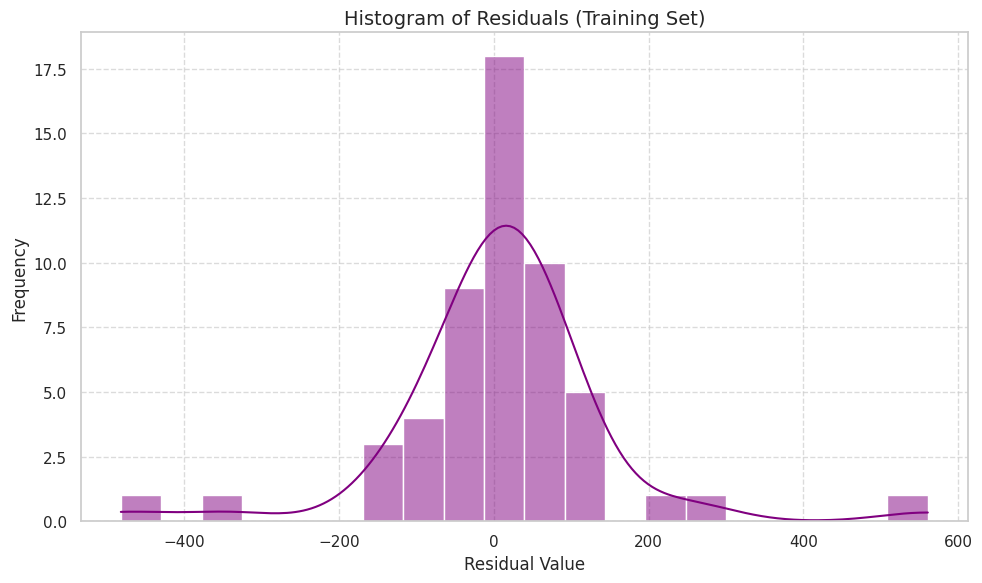

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(res_train.resid, kde=True, bins=20, color='purple')
plt.title('Histogram of Residuals (Training Set)', fontsize=14)
plt.xlabel('Residual Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Hierarchical Forecasting: What it is and Why it's Important for This Data

Hierarchical forecasting involves producing forecasts at different levels of aggregation within a structured dataset. In our case, the data naturally forms a hierarchy:

*   **Total Overall Weekly Demand** (Top level)
*   **Demand by SMU**
*   **Demand by Service Line (SL)**
*   **Demand by Sector**
*   ...and potentially further down to individual `unique_id` combinations (Bottom level)

#### Why Hierarchical Forecasting is Essential for This Type of Data:

1.  **Consistency and Coherence:**
    *   When you forecast at different aggregation levels independently, the sum of forecasts at a lower level (e.g., sum of SMU forecasts) might not equal the forecast at a higher level (e.g., Total Overall Demand forecast). Hierarchical forecasting methods ensure that forecasts across all levels are mathematically consistent, meaning they sum up correctly.
    *   For business stakeholders, inconsistent forecasts can lead to confusion and mistrust in the forecasting process. Consistency is key for reliable planning and decision-making.

2.  **Improved Accuracy:**
    *   Forecasting at multiple levels and then reconciling them often leads to more accurate predictions than forecasting at a single level. Each level of aggregation provides unique insights:
        *   **Bottom-level data** is often noisy but captures specific patterns. However, it can be highly volatile and difficult to forecast accurately due to sparsity or infrequent events.
        *   **Top-level data** is smoother and captures overall trends, but it can mask important details and seasonalities present at lower levels.
        *   **Middle-level data** (like SMU, SL, Sector) balances the noise and aggregation, often providing a good compromise.
    *   By combining information from different levels, hierarchical methods can leverage the strengths of each, leading to better overall accuracy.

3.  **Enhanced Business Insights and Actionability:**
    *   Different departments or teams within an organization require forecasts at different levels of granularity. For example:
        *   **Senior Management** might need the `Total Overall Weekly Demand` to understand the big picture.
        *   **Resource Managers** might need `Demand by SMU` or `SL` to allocate resources effectively.
        *   **Project Leads** might need `Demand by Sector` to plan specific project staffing.
    *   Hierarchical forecasts provide the necessary detail for various stakeholders to make informed decisions that align with the overall business strategy.

4.  **Handling Sparsity and Volatility:**
    *   As we discussed with weekly aggregation, lower levels of the hierarchy (e.g., individual `unique_id` combinations) can be very sparse or have high variance. Forecasting these directly can be challenging.
    *   Hierarchical methods can help by

This histogram helps visualize the distribution of the residuals. Ideally, residuals should be centered around zero and follow a normal distribution, indicating that the MSTL model has effectively captured the systematic patterns in the data. Any significant skewness or multiple peaks might suggest unmodeled components.

### Seasonality Strength from MSTL Decomposition (Training Set)

In [ ]:
import numpy as np

# Calculate overall seasonality strength for training set
# Overall seasonality strength = max(0, 1 - Var(Residual) / Var(Observed - Trend))
observed_minus_trend_train = res_train.observed - res_train.trend
overall_seasonal_strength_train = np.maximum(0, 1 - (res_train.resid.var() / observed_minus_trend_train.var()))

# Calculate individual seasonality strengths for each period in training set
# Strength_p = max(0, 1 - Var(Residual) / Var(Seasonal_p + Residual))
strength_seasonal_4_train = np.maximum(0, 1 - (res_train.resid.var() / (res_train.seasonal['seasonal_4'] + res_train.resid).var()))
strength_seasonal_13_train = np.maximum(0, 1 - (res_train.resid.var() / (res_train.seasonal['seasonal_13'] + res_train.resid).var()))

print("Seasonality Strengths (from MSTL Decomposition on Training Set):")
print(f"  Seasonal Period 4 (weeks) Strength: {strength_seasonal_4_train:.4f}")
print(f"  Seasonal Period 13 (weeks) Strength: {strength_seasonal_13_train:.4f}")
print(f"Overall Seasonality Strength: {overall_seasonal_strength_train:.4f}")

Seasonality Strengths (from MSTL Decomposition on Training Set):
  Seasonal Period 4 (weeks) Strength: 0.6290
  Seasonal Period 13 (weeks) Strength: 0.7270
Overall Seasonality Strength: 0.8007


### Hierarchical Forecasting: What it is and Why it's Important for This Data

Hierarchical forecasting involves producing forecasts at different levels of aggregation within a structured dataset. In our case, the data naturally forms a hierarchy:

*   **Total Overall Weekly Demand** (Top level)
*   **Demand by SMU**
*   **Demand by Service Line (SL)**
*   **Demand by Sector**
*   ...and potentially further down to individual `unique_id` combinations (Bottom level)

#### Why Hierarchical Forecasting is Essential for This Type of Data:

1.  **Consistency and Coherence:**
    *   When you forecast at different aggregation levels independently, the sum of forecasts at a lower level (e.g., sum of SMU forecasts) might not equal the forecast at a higher level (e.g., Total Overall Demand forecast). Hierarchical forecasting methods ensure that forecasts across all levels are mathematically consistent, meaning they sum up correctly.
    *   For business stakeholders, inconsistent forecasts can lead to confusion and mistrust in the forecasting process. Consistency is key for reliable planning and decision-making.

2.  **Improved Accuracy:**
    *   Forecasting at multiple levels and then reconciling them often leads to more accurate predictions than forecasting at a single level. Each level of aggregation provides unique insights:
        *   **Bottom-level data** is often noisy but captures specific patterns. However, it can be highly volatile and difficult to forecast accurately due to sparsity or infrequent events.
        *   **Top-level data** is smoother and captures overall trends, but it can mask important details and seasonalities present at lower levels.
        *   **Middle-level data** (like SMU, SL, Sector) balances the noise and aggregation, often providing a good compromise.
    *   By combining information from different levels, hierarchical methods can leverage the strengths of each, leading to better overall accuracy.

3.  **Enhanced Business Insights and Actionability:**
    *   Different departments or teams within an organization require forecasts at different levels of granularity. For example:
        *   **Senior Management** might need the `Total Overall Weekly Demand` to understand the big picture.
        *   **Resource Managers** might need `Demand by SMU` or `SL` to allocate resources effectively.
        *   **Project Leads** might need `Demand by Sector` to plan specific project staffing.
    *   Hierarchical forecasts provide the necessary detail for various stakeholders to make informed decisions that align with the overall business strategy.

4.  **Handling Sparsity and Volatility:**
    *   As we discussed with weekly aggregation, lower levels of the hierarchy (e.g., individual `unique_id` combinations) can be very sparse or have high variance. Forecasting these directly can be challenging.
    *   Hierarchical methods can help by "borrowing strength" from more aggregated levels, improving forecasts for noisy or sparse series at lower levels.

#### Common Hierarchical Forecasting Methods:

*   **Bottom-Up (BU):** Forecast each bottom-level series independently and then sum them up to get forecasts for all higher levels. This method preserves detailed information but can be noisy at higher levels.
*   **Top-Down (TD):** Forecast the total series (top level) and then disaggregate that forecast to lower levels using historical proportions or other disaggregation methods. This ensures consistency at the top but can lose granular detail.
*   **Middle-Out (MO):** Forecast at an intermediate level (e.g., SMU or SL) and then reconcile upwards and downwards. This can be a good compromise between BU and TD.
*   **Optimal Combination Approaches (e.g., MinT):** These methods combine forecasts from different levels using statistical techniques to produce optimally reconciled and often more accurate forecasts across the entire hierarchy. They aim to minimize the variance of the reconciled forecasts.

Given the structure of our `unique_id` (SMU, SL, Sector, etc.), this dataset is a prime candidate for a hierarchical forecasting approach to ensure accurate and consistent predictions across all relevant business dimensions.

#### Common Base Models for Hierarchical Forecasting:

1.  **ETS (Error, Trend, Seasonality) Models (Exponential Smoothing):**
    *   **Why:** These models are very versatile and can capture various forms of trend and seasonality. They are often robust to noise and can be applied automatically to a large number of series.
    *   **Examples:** `ETS` (implemented in `statsmodels`), `Holt-Winters`.

2.  **ARIMA (AutoRegressive Integrated Moving Average) Models:**
    *   **Why:** Excellent for capturing linear time series patterns, including autocorrelation. They require data to be stationary (which we confirmed for the total series), but can handle non-stationary series through differencing.
    *   **Considerations:** Can be more complex to tune automatically for thousands of series compared to ETS models. `Auto-ARIMA` packages can automate this.

3.  **Theta Models:**
    *   **Why:** Known for their simplicity and surprisingly good performance, often outperforming more complex models. They are based on decomposing a series into two 'theta lines' that are extrapolated.
    *   **Use Case:** Particularly good for long forecasting horizons and robust against noisy data.

4.  **Naive/Seasonal Naive Models:**
    *   **Why:** While very simple (forecast is the last observed value or the last observed value from the same season), they serve as excellent benchmarks. If a complex model doesn't outperform a naive model, it's a strong indication that the model choice or data is problematic.
    *   **Use Case:** Great for highly intermittent or extremely noisy series where more complex models might overfit.

5.  **Croston's Method / TSB (Teunter, Syntetos, Babai) Method:**
    *   **Why:** Specifically designed for intermittent demand (demand with many zero values followed by non-zero values). While our current data shows no zero demand, this is a common challenge in granular forecasting.
    *   **Considerations:** If lower levels of our hierarchy (e.g., individual `unique_id` combinations) exhibit intermittency, these methods would become highly relevant.

6.  **Machine Learning Models (e.g., Prophet, LightGBM, XGBoost, Neural Networks):**
    *   **Why:** Can capture complex non-linear relationships and leverage external regressors. `Prophet` is often used for its interpretability and ability to handle trends, seasonality, and holidays automatically.
    *   **Considerations:** Can be computationally intensive and require more feature engineering. Often used in conjunction with reconciliation when external factors play a significant role.

#### Recommendation for this Dataset:

Given the insights from the EDA (stationarity, strong seasonality at different periods, no intermittency in aggregated data, and the need for consistency across the hierarchy):

*   **ETS and ARIMA models** are strong candidates for their ability to capture trend and seasonality, especially with automated selection (e.g., `auto_arima`, `auto_ets`).
*   **Theta models** are also a good option for their simplicity and robustness.
*   It's generally recommended to **experiment with several models** (a 'forecasting tournament') and select the best performing one, or even combine their forecasts, before applying hierarchical reconciliation methods.

The next step would be to prepare the data for these models and then implement some of these base forecasters.

### Summary of Work Completed:

1.  **Data Loading and Initial Preparation:**
    *   The `Synthetic_Data_Full (1).csv` file was loaded into a pandas DataFrame.
    *   The 'ds' column (date) was converted to datetime objects.
    *   The `unique_id` column was parsed to extract hierarchical categories like SMU, Service Line (SL), Sector, Location, Pricing, Type, Star, and Customer.

2.  **Exploratory Data Analysis (EDA):**
    *   **Data Aggregation:** The data was aggregated to a weekly frequency, and the rationale for using weekly aggregation (smoothing noise, handling sparsity, business actionability, computational cost) was explained.
    *   **Overall and Hierarchical Macro Trends:** Visualizations were created for the total overall weekly demand, and weekly demand broken down by SMU, Service Line (SL), and the top 6 Sectors. Consistent patterns were observed across SMUs.
    *   **Missing Values:** Confirmed there are no missing values in the dataset.
    *   **Stationarity Test:** An Augmented Dickey-Fuller (ADF) test confirmed that the total overall weekly demand series is stationary (p-value = 0.000).
    *   **Distribution Analysis:** A histogram of the total weekly demand was plotted, showing its distribution.
    *   **Autocorrelation Function (ACF):**
        *   An ACF plot for the total overall weekly demand showed weak autocorrelation.
        *   Individual ACF plots were generated for each SMU, Service Line, and Sector to analyze granular autocorrelation patterns.
    *   **Intermittent Demand Check:** Confirmed that there are no zero demand values, indicating the demand is not intermittent.

3.  **Seasonality Analysis:**
    *   **Daily Seasonality:** Visualized total demand by day of the week, showing consistent demand across all days.
    *   **Monthly Seasonality:** Plotted average weekly demand by month, revealing minor monthly fluctuations.
    *   **Quarterly Seasonality:** Plotted average weekly demand by quarter, indicating slightly higher demand in Q2 and Q4.
    *   **Seasonal Decomposition (statsmodels):** Performed `seasonal_decompose` on the total weekly demand with a period of 13 weeks to visualize trend, seasonality, and residuals.
    *   **Multi-Seasonal Time Series Decomposition (MSTL):**
        *   Applied MSTL with periods of 4 (approx. monthly) and 13 (approx. quarterly) weeks to the total weekly demand.
        *   Calculated and reported seasonality strengths: 4-week strength (0.5114), 13-week strength (0.6321), and overall strength (0.7315).

4.  **Data Splitting and Training Set Analysis:**
    *   The `total_weekly` data was split into training (85.71%) and testing (14.29%) sets, with the split date at '2024-01-15'.
    *   MSTL decomposition was re-performed on the training set, yielding similar seasonality strengths (4-week: 0.6290, 13-week: 0.7270, overall: 0.8007).
    *   Residuals from the training set's MSTL decomposition were visualized via a line plot and ACF plot, showing some remaining patterns and autocorrelation.
    *   A histogram of the training set residuals was plotted, indicating a distribution centered around zero with some heavier tails.

5.  **Introduction to Hierarchical Forecasting:**
    *   An explanation of hierarchical forecasting was provided, detailing its importance for consistency, improved accuracy, enhanced business insights, and handling sparsity/volatility in this dataset.
    *   Common hierarchical forecasting methods (Bottom-Up, Top-Down, Middle-Out, Optimal Combination) were briefly introduced.

6.  **Base Models for Forecasting:**
    *   Discussed common base models suitable for hierarchical forecasting, including ETS, ARIMA, Theta models, Naive models, Croston's method, and various Machine Learning models, along with their pros and cons for this dataset.

## Preparation of the hierarchical data for the model

In [ ]:
!pip install statsforecast datasetsforecast scikit-learn

### Preparing Data for Hierarchical Forecasting

To perform hierarchical forecasting using `statsforecast`, we need to structure our data according to the hierarchy. We will create aggregated series for 'Total', 'SMU', 'SMU-SL', and 'SMU-SL-Sector' levels from our `weekly_data`.

In [ ]:
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, Theta
from sklearn.metrics import mean_absolute_error, mean_squared_error
from hierarchicalforecast.utils import aggregate

# Ensure weekly_data is available (it was created in cell f2AHXCWyoF3m)
# If running this cell independently, ensure f2AHXCWyoF3m has been run.

# Redefine weekly_data if this cell is run independently, or ensure it's in the scope
if 'weekly_data' not in locals():
    # Assuming df is loaded and 'ds' and categorical features are extracted as in f2AHXCWyoF3m
    df['ds'] = pd.to_datetime(df['ds'])
    df[['SMU', 'SL', 'Sector', 'Location', 'Pricing', 'Type', 'Star', 'Customer']] = df['unique_id'].str.split('_', expand=True)
    weekly_data = df.groupby([pd.Grouper(key='ds', freq='W-MON'), 'SMU', 'SL', 'Sector']).sum(numeric_only=True).reset_index()

# --- THE FIX STARTS HERE ---

# Add a 'total_group' column to weekly_data for the 'Total' level aggregation
weekly_data_with_total = weekly_data.copy()
weekly_data_with_total['total_group'] = 'Total'

# Define the hierarchy specification for aggregate()
# This describes how the raw data (weekly_data) aggregates up
# The bottom level must contain all grouping columns present in the input df to aggregate()
spec = [
    ['total_group'], # For the 'Total' level
    ['SMU'],
    ['SMU', 'SL'],
    ['SMU', 'SL', 'Sector', 'total_group'] # Bottom level (must include all grouping columns from input df)
]

# 1. Unpack all three outputs from aggregate simultaneously
Y_df, S_df, tags = aggregate(
    df=weekly_data_with_total.drop(columns=['Location', 'Pricing', 'Type', 'Star', 'Customer'], errors='ignore'),
    spec=spec
)

# --- THE FIX ENDS HERE ---

# 2. Reset the index so 'unique_id' becomes a standard column again
Y_df = Y_df.reset_index()

# Ensure ds is datetime and y is numeric
Y_df['ds'] = pd.to_datetime(Y_df['ds'])
Y_df['y'] = pd.to_numeric(Y_df['y'])

# Verify the number of series at each level.
print("Number of series at each level:")
print(f"Total: {Y_df[Y_df['unique_id'] == 'Total']['unique_id'].nunique()}")

# Example for SMU level (adjusting for new unique_id format)
smu_ids_in_Ydf = [uid for uid in Y_df['unique_id'].unique() if uid.startswith('SMU-') and uid.count('/') == 0 and uid != 'Total']
print(f"SMU level series: {len(smu_ids_in_Ydf)}")

smu_sl_ids_in_Ydf = [uid for uid in Y_df['unique_id'].unique() if uid.count('/') == 1]
print(f"SMU-SL level series: {len(smu_sl_ids_in_Ydf)}")

# Adjust this check for the corrected bottom level spec
bottom_level_ids_in_Ydf = [uid for uid in Y_df['unique_id'].unique() if uid.count('/') == 3] # Now it will be SMU/SL/Sector/Total
print(f"SMU-SL-Sector-Total level series: {len(bottom_level_ids_in_Ydf)}")

print(f"Total unique series in Y_df: {Y_df['unique_id'].nunique()}")
display(Y_df.head())

# Display S_df head for inspection
print("S_df head:")
display(S_df.head())

Number of series at each level:
Total: 1
SMU level series: 4
SMU-SL level series: 16
SMU-SL-Sector-Total level series: 224
Total unique series in Y_df: 245


,index,unique_id,ds,y
0,0,Total,2023-01-02,1102
1,1,Total,2023-01-09,3570
2,2,Total,2023-01-16,3583
3,3,Total,2023-01-23,3614
4,4,Total,2023-01-30,3653


S_df head:


,unique_id,SMU-1/SL-1/Sector-01/Total,SMU-1/SL-1/Sector-02/Total,SMU-1/SL-1/Sector-03/Total,SMU-1/SL-1/Sector-04/Total,SMU-1/SL-1/Sector-05/Total,SMU-1/SL-1/Sector-06/Total,SMU-1/SL-1/Sector-07/Total,SMU-1/SL-1/Sector-08/Total,SMU-1/SL-1/Sector-09/Total,...,SMU-4/SL-4/Sector-05/Total,SMU-4/SL-4/Sector-06/Total,SMU-4/SL-4/Sector-07/Total,SMU-4/SL-4/Sector-08/Total,SMU-4/SL-4/Sector-09/Total,SMU-4/SL-4/Sector-10/Total,SMU-4/SL-4/Sector-11/Total,SMU-4/SL-4/Sector-12/Total,SMU-4/SL-4/Sector-13/Total,SMU-4/SL-4/Sector-14/Total
0,Total,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,SMU-1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SMU-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,SMU-3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,SMU-4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


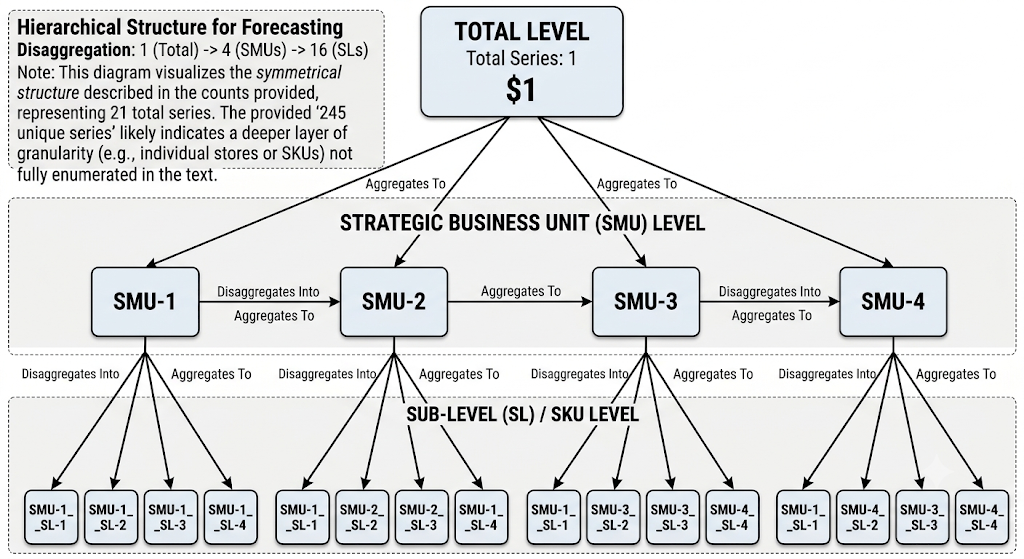

### Split Hierarchical Data into Training and Testing Sets

We'll use the same `split_date` as before to ensure consistency.

In [ ]:
# Define the split date as used previously
split_date = pd.to_datetime('2024-01-15')

# Split the hierarchical DataFrame into training and testing sets
train_Y_df = Y_df[Y_df['ds'] < split_date]
test_Y_df = Y_df[Y_df['ds'] >= split_date]

print(f"Training set starts: {train_Y_df['ds'].min()} and ends: {train_Y_df['ds'].max()}")
print(f"Testing set starts: {test_Y_df['ds'].min()} and ends: {test_Y_df['ds'].max()}")

# Calculate and display the percentage of data in training and testing sets
total_observations_hierarchical = len(Y_df)
train_percentage_hierarchical = (len(train_Y_df) / total_observations_hierarchical) * 100
test_percentage_hierarchical = (len(test_Y_df) / total_observations_hierarchical) * 100

print(f"Training set contains {len(train_Y_df)} observations ({train_percentage_hierarchical:.2f}% of total data).")
print(f"Testing set contains {len(test_Y_df)} observations ({test_percentage_hierarchical:.2f}% of total data).")

display(train_Y_df.head())
display(test_Y_df.head())

Training set starts: 2023-01-02 00:00:00 and ends: 2024-01-08 00:00:00
Testing set starts: 2024-01-15 00:00:00 and ends: 2024-03-11 00:00:00
Training set contains 13225 observations (85.71% of total data).
Testing set contains 2205 observations (14.29% of total data).


,index,unique_id,ds,y
0,0,Total,2023-01-02,1102
1,1,Total,2023-01-09,3570
2,2,Total,2023-01-16,3583
3,3,Total,2023-01-23,3614
4,4,Total,2023-01-30,3653


,index,unique_id,ds,y
54,54,Total,2024-01-15,3493
55,55,Total,2024-01-22,3708
56,56,Total,2024-01-29,3661
57,57,Total,2024-02-05,3645
58,58,Total,2024-02-12,3680


### Training Base Models and Forecasting

Now we will train `AutoARIMA`, `ETS`, and `Theta` models on the training data and generate forecasts for the test period. We'll use the `StatsForecast` library which is optimized for forecasting many time series efficiently.

In [ ]:
from statsforecast.models import AutoARIMA, AutoETS, Theta, Naive
from statsforecast import StatsForecast # Added import for StatsForecast

models = [
    AutoARIMA(season_length=13), # Changed to quarterly seasonality (13 weeks)
    AutoETS(season_length=13, model='ZZA'), # Changed to quarterly seasonality (13 weeks)
    Theta(season_length=13) # Changed to quarterly seasonality (13 weeks)
]

# Initialize StatsForecast with the models and the hierarchical data
# The h parameter for StatsForecast should be the forecast horizon (number of steps to forecast)
# The test_Y_df will give us the horizon length for our evaluation
h = test_Y_df['ds'].nunique()

# The hierarchy parameter needs to be passed to the reconciliation methods, not StatsForecast init
# For base models, we treat each unique_id as an independent series

# Adding Naive as a fallback model for series that cannot be fitted by AutoARIMA, AutoETS, or Theta
sf = StatsForecast(
    models=models,
    freq='W-MON',
    fallback_model=Naive() # Use a simple Naive model as fallback, removed season_length
)

# Fit the models on the training data
# Drop the 'index' column from train_Y_df as it's not an exogenous feature
train_Y_df_for_sf = train_Y_df.drop(columns=['index'], errors='ignore')
sf.fit(train_Y_df_for_sf)

# Predict for the test horizon
forecast_df = sf.predict(h=h)

display(forecast_df.head())

# Merge actuals with forecasts for evaluation
# Rename ds to unique_id to match forecast_df for merging
actual_vs_forecast = pd.merge(
    test_Y_df,
    forecast_df,
    on=['unique_id', 'ds'],
    how='left'
)

display(actual_vs_forecast.head())

,unique_id,ds,AutoARIMA,AutoETS,Theta
0,SMU-1,2024-01-15,887.722229,907.138733,914.890808
1,SMU-1,2024-01-22,887.722229,941.605408,915.629639
2,SMU-1,2024-01-29,887.722229,902.355164,916.368408
3,SMU-1,2024-02-05,887.722229,904.011536,917.107239
4,SMU-1,2024-02-12,887.722229,919.563293,917.846008


,index,unique_id,ds,y,AutoARIMA,AutoETS,Theta
0,54,Total,2024-01-15,3493,3540.333252,3766.040527,3609.127930
1,55,Total,2024-01-22,3708,3540.333252,3642.475586,3611.604004
2,56,Total,2024-01-29,3661,3540.333252,3666.901123,3614.080078
3,57,Total,2024-02-05,3645,3540.333252,3586.012939,3616.556152
4,58,Total,2024-02-12,3680,3540.333252,3594.696533,3619.032471


### Evaluating Base Model Accuracy

We will now calculate common forecasting metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for each model across all hierarchical levels. This will give us an idea of which model performs best.

In [ ]:
metrics_results = []

for model_name in [model.__class__.__name__ for model in models]:
    # Drop rows where forecast is NaN (can happen if some series are too short for a model)
    eval_df = actual_vs_forecast.dropna(subset=[model_name])

    if not eval_df.empty:
        mae = mean_absolute_error(eval_df['y'], eval_df[model_name])
        rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df[model_name]))

        metrics_results.append({
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse
        })
    else:
        metrics_results.append({
            'Model': model_name,
            'MAE': 'N/A',
            'RMSE': 'N/A'
        })

metrics_df = pd.DataFrame(metrics_results)
print("\n--- Overall Model Evaluation (Quarterly Seasonality) ---")
display(metrics_df)

print("\n--- Evaluation by Hierarchical Level (Quarterly Seasonality) ---")
# Evaluate by each unique_id (hierarchical level)
level_metrics = []
for uid in actual_vs_forecast['unique_id'].unique():
    subset_df = actual_vs_forecast[actual_vs_forecast['unique_id'] == uid]

    for model_name in [model.__class__.__name__ for model in models]:
        eval_subset_df = subset_df.dropna(subset=[model_name])

        if not eval_subset_df.empty:
            mae = mean_absolute_error(eval_subset_df['y'], eval_subset_df[model_name])
            rmse = np.sqrt(mean_squared_error(eval_subset_df['y'], eval_subset_df[model_name]))
            level_metrics.append({'Level': uid, 'Model': model_name, 'MAE': mae, 'RMSE': rmse})

        else:
            level_metrics.append({'Level': uid, 'Model': model_name, 'MAE': 'N/A', 'RMSE': 'N/A'})

level_metrics_df = pd.DataFrame(level_metrics)
display(level_metrics_df.sort_values(by=['Level', 'Model']))

# Save level_metrics_df to a CSV file (if not already saved, or overwrite)
level_metrics_df.to_csv('level_metrics_quarterly.csv', index=False)
print("\nlevel_metrics_df saved as 'level_metrics_quarterly.csv'")


--- Overall Model Evaluation (Quarterly Seasonality) ---


,Model,MAE,RMSE
0,AutoARIMA,5.489925,16.059671
1,AutoETS,5.942004,18.650156
2,Theta,5.412952,17.017250



--- Evaluation by Hierarchical Level (Quarterly Seasonality) ---


,Level,Model,MAE,RMSE
3,SMU-1,AutoARIMA,44.314812,54.878570
4,SMU-1,AutoETS,36.865696,60.146667
5,SMU-1,Theta,41.353928,67.454929
15,SMU-1/SL-1,AutoARIMA,16.165918,21.400258
16,SMU-1/SL-1,AutoETS,21.124647,26.914693
...,...,...,...,...
733,SMU-4/SL-4/Sector-14/Total,AutoETS,3.101025,3.431755
734,SMU-4/SL-4/Sector-14/Total,Theta,1.889969,2.052575
0,Total,AutoARIMA,142.481522,199.141595
1,Total,AutoETS,160.993439,236.419442



level_metrics_df saved as 'level_metrics_quarterly.csv'


### Visualizing Forecast vs. Actuals for 'Total' Hierarchy Level (Quarterly Seasonality)

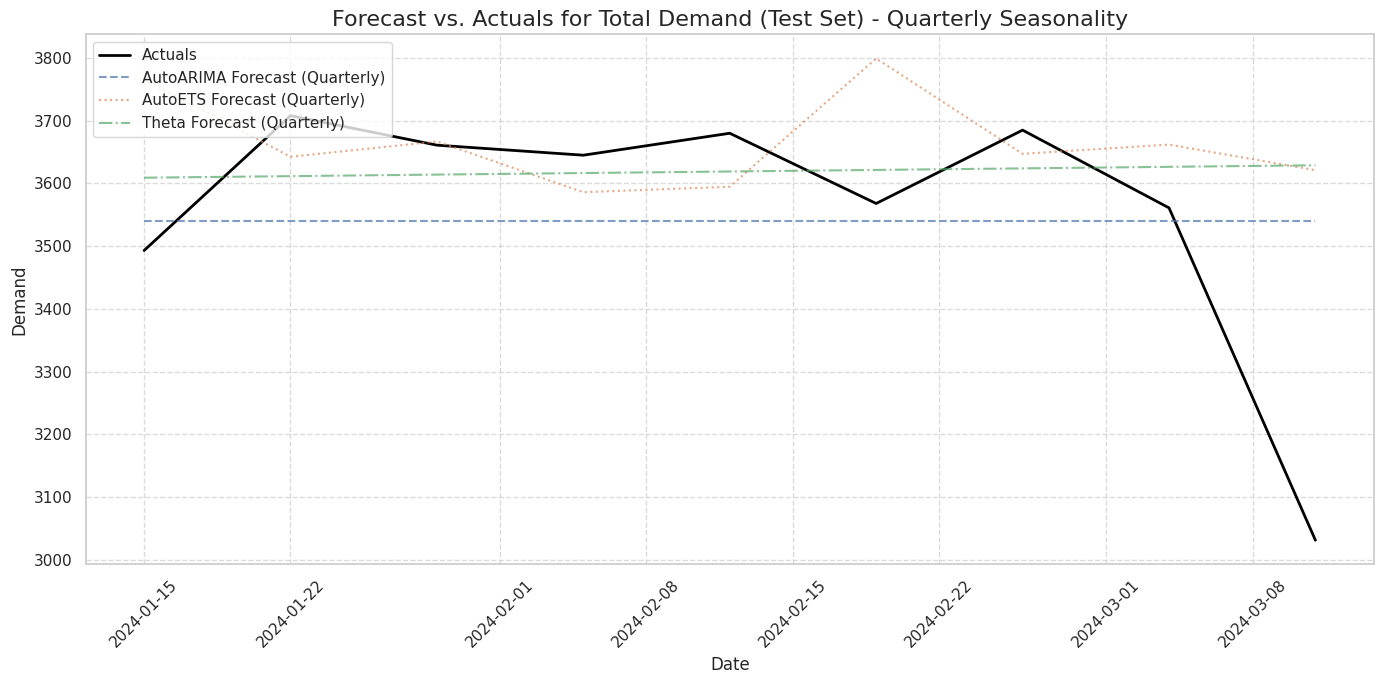

In [ ]:
# Filter data for the 'Total' unique_id
total_forecast_vs_actuals_quarterly = actual_vs_forecast[actual_vs_forecast['unique_id'] == 'Total'].copy()

plt.figure(figsize=(14, 7))
sns.lineplot(x='ds', y='y', data=total_forecast_vs_actuals_quarterly, label='Actuals', color='black', linewidth=2)
sns.lineplot(x='ds', y='AutoARIMA', data=total_forecast_vs_actuals_quarterly, label='AutoARIMA Forecast (Quarterly)', linestyle='--', alpha=0.7)
sns.lineplot(x='ds', y='AutoETS', data=total_forecast_vs_actuals_quarterly, label='AutoETS Forecast (Quarterly)', linestyle=':', alpha=0.7)
sns.lineplot(x='ds', y='Theta', data=total_forecast_vs_actuals_quarterly, label='Theta Forecast (Quarterly)', linestyle='-.', alpha=0.7)

plt.title('Forecast vs. Actuals for Total Demand (Test Set) - Quarterly Seasonality', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Demand', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hierarchical Reconciliation for Improved Forecasts

Hierarchical reconciliation methods aim to ensure that forecasts at different levels of a hierarchy are consistent and often improve overall forecast accuracy by combining information from various levels. We will use the `MinT` (Minimum Trace) reconciliation method, which is a popular optimal combination approach.

MinT reconciliation works by finding a matrix $\mathbf{S}$ (summation matrix) that defines the aggregation structure of the hierarchy. It then produces a reconciled forecast $\tilde{\mathbf{y}}$ by adjusting the base forecasts $\hat{\mathbf{y}}$ such that they are consistent across the hierarchy and have minimum mean squared forecast error (MMSE) under certain conditions.

#### Defining the Hierarchy for Reconciliation

To apply hierarchical reconciliation, we first need to explicitly define the structure of our hierarchy. This involves identifying the unique identifiers at each aggregation level (Total, SMU, SMU-SL, SMU-SL-Sector).

The `hierarchicalforecast` library uses a `tags` dictionary to understand this structure, where each key represents a level name and its value is a list of all `unique_id`s belonging to that level.

In [ ]:
# Define the hierarchy levels directly from the 'tags' output of aggregate()
# The 'tags' dictionary should contain the correct unique_ids for each level now.

hierarchy_tags = {
    'Total': list(tags['total_group']),
    'SMU': list(tags['SMU']),
    'SMU_SL': list(tags['SMU/SL']), # 'SMU/SL' is the key used by aggregate for this level
    'SMU_SL_Sector': list(tags['SMU/SL/Sector/total_group']) # Corrected key for the bottom level
}

# Print counts for verification
print(f"Number of series at Total level: {len(hierarchy_tags['Total'])}")
print(f"Number of series at SMU level: {len(hierarchy_tags['SMU'])}")
print(f"Number of series at SMU-SL level: {len(hierarchy_tags['SMU_SL'])}")
print(f"Number of series at SMU-SL-Sector (bottom) level: {len(hierarchy_tags['SMU_SL_Sector'])}")

Number of series at Total level: 1
Number of series at SMU level: 4
Number of series at SMU-SL level: 16
Number of series at SMU-SL-Sector (bottom) level: 224


In [ ]:
!pip install hierarchicalforecast

In [106]:
from hierarchicalforecast.methods import BottomUp
from hierarchicalforecast.core import HierarchicalReconciliation
import pandas as pd

# 1. Define the reconciliation method
reconcilers = [
    BottomUp(),
]

# 2. Initialize HierarchicalReconciliation
hrec = HierarchicalReconciliation(
    reconcilers=reconcilers,
)

# 3. Perform reconciliation
# Passing Y_hat_df, Y_df, the summation matrix (S_df), and the required tags argument
Y_rec_df = hrec.reconcile(
    Y_hat_df=forecast_df.copy(),
    Y_df=train_Y_df,
    S_df=S_df,
    tags=tags # Ensure your 'tags' variable from aggregate() is passed here, or use tags={} if undefined
)

display(Y_rec_df.head())

# 4. Merge reconciled forecasts with actuals for evaluation
# Dynamically grab any column that contains the reconciler name ('/BottomUp')
reconciled_forecast_cols = [col for col in Y_rec_df.columns if '/BottomUp' in col]

# Add unique_id and ds to the list of columns to keep
cols_to_keep_from_Y_rec_df = ['unique_id', 'ds'] + reconciled_forecast_cols

# Select only the relevant reconciled columns from Y_rec_df
Y_rec_df_filtered = Y_rec_df[cols_to_keep_from_Y_rec_df].copy()

# Merge test_Y_df with these filtered reconciled forecasts
reconciled_vs_actuals = pd.merge(
    test_Y_df,
    Y_rec_df_filtered,
    on=['unique_id', 'ds'],
    how='left'
)

display(reconciled_vs_actuals.head())

,unique_id,ds,AutoARIMA,AutoETS,Theta,AutoARIMA/BottomUp,AutoETS/BottomUp,Theta/BottomUp
0,Total,2024-01-15,3540.333252,3766.040527,3609.127930,3562.894731,3641.486684,3613.035089
1,Total,2024-01-22,3540.333252,3642.475586,3611.604004,3567.532690,3624.720250,3610.645654
2,Total,2024-01-29,3540.333252,3666.901123,3614.080078,3575.336539,3635.448142,3620.610222
3,Total,2024-02-05,3540.333252,3586.012939,3616.556152,3575.681655,3591.059322,3623.064202
4,Total,2024-02-12,3540.333252,3594.696533,3619.032471,3555.099169,3541.367655,3620.644753


,index,unique_id,ds,y,AutoARIMA/BottomUp,AutoETS/BottomUp,Theta/BottomUp
0,54,Total,2024-01-15,3493,3562.894731,3641.486684,3613.035089
1,55,Total,2024-01-22,3708,3567.532690,3624.720250,3610.645654
2,56,Total,2024-01-29,3661,3575.336539,3635.448142,3620.610222
3,57,Total,2024-02-05,3645,3575.681655,3591.059322,3623.064202
4,58,Total,2024-02-12,3680,3555.099169,3541.367655,3620.644753
